In [1]:
pip install deep-translator

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from deep_translator import GoogleTranslator

# Data translating and saving

In [3]:
data = pd.read_csv("H:\\Work\\RunningWork\\grad\\landmarks\\Cairo Tourist Attractions.csv")

In [4]:
data.head()

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,Landmark,برج القاهرة,4.3,29908.0,NaN,\nشارع قصر النيل، الزمالك، محافظة القاهرة‬ 42...,227365112.0,NaN,مغلق · يفتح عند الساعة ٩ ص,برج على شكل زهرة اللوتس تكسوه 8 ملايين حجر فسي...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...
1,Landmark,ميدان طلعت حرب,4.5,22548.0,NaN,\nشارع طلعت حرب، باب اللوق، قسم قصر النيل، مح...,NaN,NaN,مفتوح على مدار الساعة,تقاطع طرق رئيسي يضمّ تمثالاً يحمل رمزًا وطنيًا...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...
2,Landmark,ميدان التحرير,4.6,5206.0,NaN,\nميدان التحرير، محطة السادات، قسم قصر النيل،...,NaN,NaN,NaN,إضافة رقم الهاتف للمكان,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...
3,Landmark,باب زويلة,4.7,2895.0,NaN,\n27V5+545، محمد علي، الدرب الأحمر، محافظة ال...,NaN,https://www.archnet.org/sites/2728,مفتوح على مدار الساعة,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...
4,Landmark,قلعة صلاح الدين,4.6,35069.0,NaN,NaN,225121735.0,https://egymonuments.gov.eg/ar/archaeological-...,NaN,حصن مهيب وجدار بناه صلاح الدين في القرن الـ12 ...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...


In [5]:
data.isnull().sum().sum()

np.int64(3124)

In [6]:
data.isnull().sum()

Category             0
Name                 0
Rating              41
Review Count        41
Price Range        998
Address             45
Phone              348
Website            531
Opening Hours      300
Description        820
Photo URLs           0
Latitude             0
Longitude            0
Google Maps URL      0
dtype: int64

In [7]:
data.isnull()

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,False,False,False,False,True,False,False,True,False,False,False,False,False,False
1,False,False,False,False,True,False,True,True,False,False,False,False,False,False
2,False,False,False,False,True,False,True,True,True,False,False,False,False,False
3,False,False,False,False,True,False,True,False,False,True,False,False,False,False
4,False,False,False,False,True,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,False,False,True,True,True,False,False,True,False,False,False,False,False,False
1046,False,False,False,False,True,False,True,True,False,True,False,False,False,False
1047,False,False,True,True,True,True,True,True,True,True,False,False,False,False
1048,False,False,False,False,True,False,True,True,False,True,False,False,False,False


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         1050 non-null   object 
 1   Name             1050 non-null   object 
 2   Rating           1009 non-null   float64
 3   Review Count     1009 non-null   float64
 4   Price Range      52 non-null     object 
 5   Address          1005 non-null   object 
 6   Phone            702 non-null    float64
 7   Website          519 non-null    object 
 8   Opening Hours    750 non-null    object 
 9   Description      230 non-null    object 
 10  Photo URLs       1050 non-null   object 
 11  Latitude         1050 non-null   float64
 12  Longitude        1050 non-null   float64
 13  Google Maps URL  1050 non-null   object 
dtypes: float64(5), object(9)
memory usage: 115.0+ KB


In [9]:
text_cols = ['Name', 'Address', 'Opening Hours', 'Description']

In [10]:
translator = GoogleTranslator(source='auto', target='en')
def contains_arabic(text):
    if pd.isna(text):
        return False
    return bool(re.search(r'[\u0600-\u06FF]', str(text)))

In [11]:
def safe_translate(text):
    if pd.isna(text) or str(text).strip() == '':
        return text
    if not contains_arabic(str(text)):
        return text  # Already English/numbers, skip
    try:
        result = translator.translate(str(text))
        time.sleep(0.3)  # Small delay to avoid rate limiting
        return result
    except Exception:
        return text  # Keep original if translation fails

In [12]:
for col in text_cols:
    print(f"Translating column: {col}...")
    mask = data[col].apply(contains_arabic)
    indices = data[mask].index
    print(f"  {len(indices)} Arabic rows found")

    for i, idx in enumerate(indices):
        data.at[idx, col] = safe_translate(data.at[idx, col])
        if (i + 1) % 100 == 0:
            print(f"  Progress: {i+1}/{len(indices)}")

    print(f"  ✓ Done!")

Translating column: Name...
  582 Arabic rows found
  Progress: 100/582
  Progress: 200/582
  Progress: 300/582
  Progress: 400/582
  Progress: 500/582
  ✓ Done!
Translating column: Address...
  997 Arabic rows found
  Progress: 100/997
  Progress: 200/997
  Progress: 300/997
  Progress: 400/997
  Progress: 500/997
  Progress: 600/997
  Progress: 700/997
  Progress: 800/997
  Progress: 900/997
  ✓ Done!
Translating column: Opening Hours...
  750 Arabic rows found
  Progress: 100/750
  Progress: 200/750
  Progress: 300/750
  Progress: 400/750
  Progress: 500/750
  Progress: 600/750
  Progress: 700/750
  ✓ Done!
Translating column: Description...
  230 Arabic rows found
  Progress: 100/230
  Progress: 200/230
  ✓ Done!


In [13]:
data.to_csv('H:\\Work\\RunningWork\\grad\\landmarks\\places&landmarks.csv', index=False)
print("\nFile saved as places&landmarks.csv")
print(data[['Category', 'Name', 'Address']].head(5))


File saved as places&landmarks.csv
   Category                Name  \
0  Landmark         Cairo Tower   
1  Landmark  Talaat Harb Square   
2  Landmark       Tahrir Square   
3  Landmark          Bab Zuwila   
4  Landmark     Saladin Citadel   

                                             Address  
0  \nQasr El Nil Street, Zamalek, Cairo Governor...  
1  \nTalaat Harb Street, Bab El Louk, Qasr El Ni...  
2  \nTahrir Square, Sadat Station, Qasr El Nil D...  
3  \n27V5+545, Muhammad Ali, Al-Darb Al-Ahmar, C...  
4                                                NaN  


In [14]:
df = pd.read_csv('H:\\Work\\RunningWork\\grad\\landmarks\\places&landmarks.csv')

In [15]:
df

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,Landmark,Cairo Tower,4.3,29908.0,NaN,"\nQasr El Nil Street, Zamalek, Cairo Governor...",2.273651e+08,NaN,Closed · Opens at 9am,A lotus-shaped tower covered with 8 million mo...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...
1,Landmark,Talaat Harb Square,4.5,22548.0,NaN,"\nTalaat Harb Street, Bab El Louk, Qasr El Ni...",NaN,NaN,Open around the clock,A major intersection featuring a statue bearin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...
2,Landmark,Tahrir Square,4.6,5206.0,NaN,"\nTahrir Square, Sadat Station, Qasr El Nil D...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...
3,Landmark,Bab Zuwila,4.7,2895.0,NaN,"\n27V5+545, Muhammad Ali, Al-Darb Al-Ahmar, C...",NaN,https://www.archnet.org/sites/2728,Open around the clock,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...
4,Landmark,Saladin Citadel,4.6,35069.0,NaN,NaN,2.251217e+08,https://egymonuments.gov.eg/ar/archaeological-...,NaN,An imposing fortress and wall built by Saladin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,Day Trip Site,Trips to El Fayoum From Cairo,NaN,NaN,NaN,"\n39 Mohamed Farid Street, Al-Fawala, Abdeen,...",1.503044e+09,NaN,Open around the clock,Add the website,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.049106,31.243949,https://www.google.com/maps/place/Trips+to+El+...
1046,Day Trip Site,Pyramid of Hetepheres,4.8,9.0,NaN,"\nQ6Q5+FQQ, Dahshour facility, desert back of...",NaN,NaN,Open · Closes at 4pm,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.788719,31.209484,https://www.google.com/maps/place/Pyramid+of+H...
1047,Day Trip Site,Dahshwar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.748365,31.246487,https://www.google.com/maps/place/%D8%AF%D9%87...
1048,Day Trip Site,Satellite pyramid,4.5,52.0,NaN,"\nQ6Q5+GQQ, Badrashin Center, Giza Governorat...",NaN,NaN,Open around the clock,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.788831,31.209487,https://www.google.com/maps/place/Satellite+py...


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         1050 non-null   object 
 1   Name             1050 non-null   object 
 2   Rating           1009 non-null   float64
 3   Review Count     1009 non-null   float64
 4   Price Range      52 non-null     object 
 5   Address          1005 non-null   object 
 6   Phone            702 non-null    float64
 7   Website          519 non-null    object 
 8   Opening Hours    750 non-null    object 
 9   Description      230 non-null    object 
 10  Photo URLs       1050 non-null   object 
 11  Latitude         1050 non-null   float64
 12  Longitude        1050 non-null   float64
 13  Google Maps URL  1050 non-null   object 
dtypes: float64(5), object(9)
memory usage: 115.0+ KB


In [17]:
print(len(df))

1050


In [18]:
# Find rows in original data that are missing in the translated df
missing_rows = data[~data['Name'].isin(df['Name'])]
print(missing_rows[['Name', 'Address', 'Opening Hours', 'Description']])

Empty DataFrame
Columns: [Name, Address, Opening Hours, Description]
Index: []


In [19]:
# Find the missing rows by comparing indexes or Names
missing_rows = data[~data.index.isin(df.index)]
print(missing_rows)

Empty DataFrame
Columns: [Category, Name, Rating, Review Count, Price Range, Address, Phone, Website, Opening Hours, Description, Photo URLs, Latitude, Longitude, Google Maps URL]
Index: []


In [20]:
print(f"Missing row indices: {missing_rows.index.tolist()}")
print(f"Total missing: {len(missing_rows)}")

Missing row indices: []
Total missing: 0


In [21]:
# Find names in original data that are missing in the translated df
missing_names = data[~data['Name'].isin(df['Name'])]['Name']
print(missing_names)

Series([], Name: Name, dtype: object)


In [22]:
print(data[~data['Name'].isin(df['Name'])]['Name'].tolist())

[]


In [23]:
print(df[~df['Name'].isin(df['Name'])]['Name'].tolist())

[]


In [ ]:
def contains_arabic(text):
    if pd.isna(text):
        return False
    return bool(re.search(r'[\u0600-\u06FF]', str(text)))

# Find rows where Name still contains Arabic
still_arabic = df[df['Name'].apply(contains_arabic)]
print(f"Names still in Arabic: {len(still_arabic)}")
print(still_arabic['Name'].tolist())

Names still in Arabic: 8
['عثمان كتخدا او مسجد الكخيا', 'مسجد و خانقاه الناصر فرج بن برقوق', 'مسجد الظاهر بيبرس', 'مركز مولانا ازاد الثقافى الهندى', 'المعهد الهولندى الفلمنكى بالقاهرة - ان فى اى سى', 'دار الثقافه العربيه', 'مطعم وكافيه الهضبة', 'مطعم وكافيه اولدش']


In [ ]:
translator = GoogleTranslator(source='auto', target='en')

still_arabic = df[df['Name'].apply(contains_arabic)]

for idx in still_arabic.index:
    original = df.at[idx, 'Name']
    try:
        translated = translator.translate(str(original))
        df.at[idx, 'Name'] = translated
        print(f"✓ {original}  →  {translated}")
        time.sleep(0.3)  # longer delay this time
    except Exception as e:
        print(f"✗ Failed at index {idx} — {original}: {e}")

# Verify
remaining = df[df['Name'].apply(contains_arabic)]
print(f"\nStill Arabic after fix: {len(remaining)}")

# Save
import csv
df.to_csv('H:\\Work\\RunningWork\\grad\\landmarks\\places&landmarks.csv', index=False, quoting=csv.QUOTE_ALL)
print("Saved!")

✓ عثمان كتخدا او مسجد الكخيا  →  عثمان كتخدا او مسجد الكخيا
✓ مسجد و خانقاه الناصر فرج بن برقوق  →  مسجد و خانقاه الناصر فرج بن برقوق
✓ مسجد الظاهر بيبرس  →  مسجد الظاهر بيبرس
✓ مركز مولانا ازاد الثقافى الهندى  →  مركز مولانا ازاد الثقافى الهندى
✓ المعهد الهولندى الفلمنكى بالقاهرة - ان فى اى سى  →  المعهد الهولندى الفلمنكى بالقاهرة - ان فى اى سى
✓ دار الثقافه العربيه  →  دار الثقافه العربيه
✓ مطعم وكافيه الهضبة  →  مطعم وكافيه الهضبة
✓ مطعم وكافيه اولدش  →  مطعم وكافيه اولدش

Still Arabic after fix: 8
Saved!


In [ ]:
def contains_arabic(text):
    if pd.isna(text):
        return False
    return bool(re.search(r'[\u0600-\u06FF]', str(text)))

# Find rows where Name still contains Arabic
still_arabic = df[df['Name'].apply(contains_arabic)]
print(f"Names still in Arabic: {len(still_arabic)}")
print(still_arabic['Name'].tolist())

Names still in Arabic: 8
['عثمان كتخدا او مسجد الكخيا', 'مسجد و خانقاه الناصر فرج بن برقوق', 'مسجد الظاهر بيبرس', 'مركز مولانا ازاد الثقافى الهندى', 'المعهد الهولندى الفلمنكى بالقاهرة - ان فى اى سى', 'دار الثقافه العربيه', 'مطعم وكافيه الهضبة', 'مطعم وكافيه اولدش']


In [27]:
remaining = df[df['Name'].apply(contains_arabic)]
print(f"Still Arabic: {len(remaining)}")
print(remaining['Name'].tolist())

Still Arabic: 8
['عثمان كتخدا او مسجد الكخيا', 'مسجد و خانقاه الناصر فرج بن برقوق', 'مسجد الظاهر بيبرس', 'مركز مولانا ازاد الثقافى الهندى', 'المعهد الهولندى الفلمنكى بالقاهرة - ان فى اى سى', 'دار الثقافه العربيه', 'مطعم وكافيه الهضبة', 'مطعم وكافيه اولدش']


In [28]:
manual_translations = {
    'عثمان كتخدا او مسجد الكخيا': 'Othman Katkhuda Mosque',
    'مسجد و خانقاه الناصر فرج بن برقوق': 'Mosque and Khanqah of Al-Nasir Faraj ibn Barquq',
    'مسجد الظاهر بيبرس': 'Al-Zahir Baybars Mosque',
    'مركز مولانا ازاد الثقافى الهندى': 'Maulana Azad Indian Cultural Center',
    'المعهد الهولندى الفلمنكى بالقاهرة - ان فى اى سى': 'Netherlands Flemish Institute in Cairo - NVIC',
    'دار الثقافه العربيه': 'Arab Cultural House',
    'مطعم وكافيه الهضبة': 'Al-Hadaba Restaurant and Cafe',
    'مطعم وكافيه اولدش': 'Oldish Restaurant and Cafe'
}

for idx, row in df[df['Name'].apply(contains_arabic)].iterrows():
    df.at[idx, 'Name'] = manual_translations[row['Name']]

# Verify
remaining = df[df['Name'].apply(contains_arabic)]
print(f"Still Arabic: {len(remaining)}")  # Should print 0

# Save
import csv
df.to_csv('H:\\Work\\RunningWork\\grad\\landmarks\\places&landmarks.csv', index=False, quoting=csv.QUOTE_ALL)
print("Saved!")

Still Arabic: 0
Saved!


In [29]:
# Check all 3 columns for any remaining Arabic
mask = (df['Address'].apply(contains_arabic) | 
        df['Opening Hours'].apply(contains_arabic) | 
        df['Description'].apply(contains_arabic))

remaining = df[mask]
print(f"Still Arabic: {len(remaining)}")
print(remaining[['Name', 'Address', 'Opening Hours', 'Description']].to_string())

Still Arabic: 7
                         Name                                                                                      Address                           Opening Hours                                                                                                    Description
73   Pyramid of Queen Hnutsen                   \nX4HP+4GJ، حارة الحسين بن علي، نزلة السمان، الهرم، محافظة الجيزة 3512201                   Closed · Opens at 7am  An unfinished pyramid in the Giza necropolis, believed to be the burial place of the ancient queen Henut-Sen.
326              Miss Fatakat         \nX35Q+MPR، الجيش، الظهير الصحراوى لمحافظة الجيزة،، قسم أول 6 أكتوبر، محافظة الجيزة                   Closed · Opens at 8am                                                                                                            NaN
523           El Shaer Stable                           \nX4GR+V99، امرؤ القيس، نزلة السمان، الهرم، محافظة الجيزة 3514541                   Open around the clock

In [30]:
from deep_translator import GoogleTranslator
import time

translator = GoogleTranslator(source='auto', target='en')

arabic_address = df[df['Address'].apply(contains_arabic)]
print(f"Arabic addresses to fix: {len(arabic_address)}")

for idx in arabic_address.index:
    original = df.at[idx, 'Address']
    try:
        translated = translator.translate(str(original))
        df.at[idx, 'Address'] = translated
        print(f"✓ Index {idx}: {translated}")
        time.sleep(0.3)
    except Exception as e:
        print(f"✗ Failed at index {idx}: {e}")

# Verify
remaining = df[df['Address'].apply(contains_arabic)]
print(f"\nStill Arabic in Address: {len(remaining)}")

# Save
import csv
df.to_csv('H:\\Work\\RunningWork\\grad\\landmarks\\places&landmarks.csv', index=False, quoting=csv.QUOTE_ALL)
print("Saved!")

Arabic addresses to fix: 7
✓ Index 73: 
X4HP+4GJ، حارة الحسين بن علي، نزلة السمان، الهرم، محافظة الجيزة 3512201
✓ Index 326: 
X35Q+MPR، الجيش، الظهير الصحراوى لمحافظة الجيزة،، قسم أول 6 أكتوبر، محافظة الجيزة
✓ Index 523: 
X4GR+V99، امرؤ القيس، نزلة السمان، الهرم، محافظة الجيزة 3514541
✓ Index 541: 
X47V+C3X اسطبل الوادي، مساكن كفر الجبل، الهرم، محافظة الجيزة 3514102
✓ Index 754: 
X4MV+W8, 9 شارع مدرسه الحلميه من, شارع أبو الهول السياحي، الهرم، محافظة الجيزة
✓ Index 848: 
Semiramis InterContinental, Corniche El Nile Cairo، 11511
✓ Index 923: 
X748+JRQ، ميدان مصطفى كامل، معادي السرايات الغربية، قسم المعادي، محافظة القاهرة‬ 4212031

Still Arabic in Address: 7
Saved!


In [31]:
still_arabic_addr = df[df['Address'].apply(contains_arabic)][['Name', 'Address']]
print(still_arabic_addr.to_string())

                         Name                                                                                      Address
73   Pyramid of Queen Hnutsen                   \nX4HP+4GJ، حارة الحسين بن علي، نزلة السمان، الهرم، محافظة الجيزة 3512201
326              Miss Fatakat         \nX35Q+MPR، الجيش، الظهير الصحراوى لمحافظة الجيزة،، قسم أول 6 أكتوبر، محافظة الجيزة
523           El Shaer Stable                           \nX4GR+V99، امرؤ القيس، نزلة السمان، الهرم، محافظة الجيزة 3514541
541         Sahbe Khil stable                      \nX47V+C3X اسطبل الوادي، مساكن كفر الجبل، الهرم، محافظة الجيزة 3514102
754               Tobaz Bazar            \nX4MV+W8, 9 شارع مدرسه الحلميه من, شارع أبو الهول السياحي، الهرم، محافظة الجيزة
848               Night & Day                                 \nSemiramis InterContinental, Corniche El Nile Cairo، 11511
923        The Maidan Gardens  \nX748+JRQ، ميدان مصطفى كامل، معادي السرايات الغربية، قسم المعادي، محافظة القاهرة‬ 4212031


In [32]:
manual_addresses = {
    73:  'X4HP+4GJ, Al-Hussein bin Ali Alley, Nazlet El-Samman, Al-Haram, Giza Governorate 3512201',
    326: 'X35Q+MPR, Al-Gaysh, Desert Hinterland of Giza, First District 6th of October, Giza Governorate',
    523: 'X4GR+V99, Imru Al-Qays, Nazlet El-Samman, Al-Haram, Giza Governorate 3514541',
    541: 'X47V+C3X, Istal Al-Wadi, Kafr Al-Jabal Residences, Al-Haram, Giza Governorate 3514102',
    754: 'X4MV+W8, 9 Al-Helmiya School Street, Abu Al-Houl Al-Siyahi Street, Al-Haram, Giza Governorate',
    848: 'Semiramis InterContinental, Corniche El Nile Cairo, 11511',
    923: 'X748+JRQ, Mustafa Kamel Square, Maadi Al-Sarayat Al-Gharbiya, Maadi District, Cairo Governorate 4212031'
}

for idx, address in manual_addresses.items():
    df.at[idx, 'Address'] = address

# Verify
remaining = df[df['Address'].apply(contains_arabic)]
print(f"Still Arabic in Address: {len(remaining)}")  # Should be 0

# Save
import csv
df.to_csv('H:\\Work\\RunningWork\\grad\\landmarks\\places&landmarks.csv', index=False, quoting=csv.QUOTE_ALL)
print("Saved!")

Still Arabic in Address: 0
Saved!


In [33]:
text_cols = ['Category', 'Name', 'Address', 'Opening Hours', 'Description']

for col in text_cols:
    arabic_count = df[col].apply(contains_arabic).sum()
    print(f"{col}: {arabic_count} Arabic values remaining")

Category: 0 Arabic values remaining
Name: 0 Arabic values remaining
Address: 0 Arabic values remaining
Opening Hours: 0 Arabic values remaining
Description: 0 Arabic values remaining


# Data Cleaning

In [28]:
df = pd.read_csv("H:\\Work\\RunningWork\\grad\\landmarks\\places&landmarks.csv")

In [29]:
df.head()

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,Landmark,Cairo Tower,4.3,29908.0,NaN,"\nQasr El Nil Street, Zamalek, Cairo Governor...",227365112.0,NaN,Closed · Opens at 9am,A lotus-shaped tower covered with 8 million mo...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...
1,Landmark,Talaat Harb Square,4.5,22548.0,NaN,"\nTalaat Harb Street, Bab El Louk, Qasr El Ni...",NaN,NaN,Open around the clock,A major intersection featuring a statue bearin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...
2,Landmark,Tahrir Square,4.6,5206.0,NaN,"\nTahrir Square, Sadat Station, Qasr El Nil D...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...
3,Landmark,Bab Zuwila,4.7,2895.0,NaN,"\n27V5+545, Muhammad Ali, Al-Darb Al-Ahmar, C...",NaN,https://www.archnet.org/sites/2728,Open around the clock,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...
4,Landmark,Saladin Citadel,4.6,35069.0,NaN,NaN,225121735.0,https://egymonuments.gov.eg/ar/archaeological-...,NaN,An imposing fortress and wall built by Saladin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         1050 non-null   object 
 1   Name             1050 non-null   object 
 2   Rating           1009 non-null   float64
 3   Review Count     1009 non-null   float64
 4   Price Range      52 non-null     object 
 5   Address          1005 non-null   object 
 6   Phone            702 non-null    float64
 7   Website          519 non-null    object 
 8   Opening Hours    750 non-null    object 
 9   Description      230 non-null    object 
 10  Photo URLs       1050 non-null   object 
 11  Latitude         1050 non-null   float64
 12  Longitude        1050 non-null   float64
 13  Google Maps URL  1050 non-null   object 
dtypes: float64(5), object(9)
memory usage: 115.0+ KB


In [31]:
df.isnull().sum()

Category             0
Name                 0
Rating              41
Review Count        41
Price Range        998
Address             45
Phone              348
Website            531
Opening Hours      300
Description        820
Photo URLs           0
Latitude             0
Longitude            0
Google Maps URL      0
dtype: int64

In [32]:
df.isnull()

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,False,False,False,False,True,False,False,True,False,False,False,False,False,False
1,False,False,False,False,True,False,True,True,False,False,False,False,False,False
2,False,False,False,False,True,False,True,True,True,False,False,False,False,False
3,False,False,False,False,True,False,True,False,False,True,False,False,False,False
4,False,False,False,False,True,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,False,False,True,True,True,False,False,True,False,False,False,False,False,False
1046,False,False,False,False,True,False,True,True,False,True,False,False,False,False
1047,False,False,True,True,True,True,True,True,True,True,False,False,False,False
1048,False,False,False,False,True,False,True,True,False,True,False,False,False,False


In [33]:
df[df['Review Count'] <= 128].sort_values(by='Review Count', ascending=False)

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
952,Park / Garden,Hadayek Al Ahram Metro Station,4.3,128.0,NaN,"\nYouth Housing Road, Plateau Al-Ahram, Al-Ha...",NaN,NaN,NaN,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.988864,31.099185,https://www.google.com/maps/place/%D9%85%D8%AD...
660,Gold & Jewelry Market,Golden Bird Bazaar,4.7,128.0,NaN,"\nZaghloul, Nazlet El-Semman, Al-Haram, Giza ...",1.003507e+09,https://instagram.com/goldenbirdbazaar?igshid=...,Closed · Opens at 9:30 AM,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.983404,31.146084,https://www.google.com/maps/place/Golden+Bird+...
102,Islamic Monument,Khayr Bey Mosque,4.7,128.0,NaN,"\n27P6+838, Bab Al-Wazir, Al-Darb Al-Ahmar, C...",NaN,NaN,Closed · Opens at 9am,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.035778,31.260216,https://www.google.com/maps/place/%D9%85%D8%B3...
111,Islamic Monument,Razzaz House,4.6,125.0,NaN,"\n30°02′N 31°15′E, 15 33, Cairo Governorate",NaN,NaN,NaN,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.037548,31.259221,https://www.google.com/maps/place/%D8%A8%D9%8A...
457,Nile Cruise,Nile Dinner Cruise,4.4,125.0,NaN,NaN,1.008030e+09,https://nile-dinner-cruise.com/,NaN,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.978638,31.232394,https://www.google.com/maps/place/Nile+Dinner+...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
743,Souvenir Shop,"Copper, papyrus & lamps",5.0,1.0,NaN,"\n6, Al-Silhdar Quarter, Al-Gamaleya, Al-Gama...",NaN,NaN,NaN,NaN,https://maps.gstatic.com/tactile/pane/default_...,30.047800,31.261415,"https://www.google.com/maps/place/Copper,+papy..."
263,Cultural Center,Chollowood,5.0,1.0,NaN,"\n24, country hills, heliopolis, Cairo Govern...",1.141369e+09,NaN,NaN,NaN,https://maps.gstatic.com/tactile/pane/default_...,30.060942,31.219709,https://www.google.com/maps/place/Chollowood/@...
176,Coptic Site,Cemitério Copta,5.0,1.0,NaN,"\n263J+WCM, Kom Ghorab, Old Cairo District, C...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.004844,31.231062,https://www.google.com/maps/place/Cemit%C3%A9r...
178,Coptic Site,Cemetery of the late Ensaf,5.0,1.0,NaN,"\n263M+QF5, Qasr Al-Shamaa, Kom Ghorab, Old C...",NaN,NaN,NaN,Add the phone number to the place,https://maps.gstatic.com/tactile/pane/default_...,30.004377,31.233728,https://www.google.com/maps/place/%D9%85%D8%AF...


In [35]:
# Count rows where Review Count is 12 or less
count = df[df['Review Count'] <= 12].shape[0]
print(f"Rows with Review Count <= 12: {count}")

Rows with Review Count <= 12: 141


In [36]:
# Delete rows where Review Count is 12 or less
df = df[df['Review Count'] > 12]

# Verify
print(f"Rows remaining: {len(df)}")

Rows remaining: 868


In [37]:
categories_to_filter = [
    'Food Tour', 'Park / Garden', 'Day Trip Site', 'Escape Room',
    'Bazaar / Souq', 'Horse Riding', 'Sport & Recreation', 'Cultural Center',
    'Souvenir Shop', 'Gold & Jewelry Market', 'Zoo / Aquarium', 'Theme Park', 'Activity'
]

# Count first
count = df[(df['Review Count'] <= 128) & (df['Category'].isin(categories_to_filter))].shape[0]
print(f"Rows to be deleted: {count}")

Rows to be deleted: 185


In [38]:
# Delete
df = df[~((df['Review Count'] <= 128) & (df['Category'].isin(categories_to_filter)))]

print(f"Rows remaining: {len(df)}")

Rows remaining: 683


In [42]:
names_to_remove = [
    # Nonsensical / corrupted names
    'Issam Mendy was stabbed',
    'His suffocation is poking him badly',
    'wael zamora',
    'Nouri Al-Hadidi',
    'For free',
    'Show',
    'Souq',
    '113 l',
    'Ägypten',
    'Finca el paraiso',
    'LOTE EL CAIRO',
    'orascomtourism',
    'Place for the disabled',

    # Tour companies (not actual attractions)
    'Ancient Millennium tours',
    'Cairo tours & pakages / Egypt tours',
    'Pharaohs Land Tours',
    'Cairo day Trips',
    'f15 Broadcast Agencies',

    # Spam / fake businesses
    'Best offer ever (All u Need)',
    'Romia Shopping | Romans Shopping',
    'eltorgman mall egypt',
    'web mall',
    'shopping cairo',
    'Down Town Mall',
    'AlEman for Computer',
    'Goldsmiths are safe',

    # Foreign language duplicates
    'Cemitério Copta',
    'Souk Caire',
    'Point de vue sur les pyramides',
]

df = df[~df['Name'].isin(names_to_remove)]

# Also remove rating=5 with only 1 review (statistically unreliable)
df = df[~((df['Rating'] == 5.0) & (df['Review Count'] == 1.0))]

print(f"Rows remaining: {len(df)}")

Rows remaining: 681


In [43]:
df

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,Landmark,Cairo Tower,4.3,29908.0,NaN,"\nQasr El Nil Street, Zamalek, Cairo Governor...",2.273651e+08,NaN,Closed · Opens at 9am,A lotus-shaped tower covered with 8 million mo...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...
1,Landmark,Talaat Harb Square,4.5,22548.0,NaN,"\nTalaat Harb Street, Bab El Louk, Qasr El Ni...",NaN,NaN,Open around the clock,A major intersection featuring a statue bearin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...
2,Landmark,Tahrir Square,4.6,5206.0,NaN,"\nTahrir Square, Sadat Station, Qasr El Nil D...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...
3,Landmark,Bab Zuwila,4.7,2895.0,NaN,"\n27V5+545, Muhammad Ali, Al-Darb Al-Ahmar, C...",NaN,https://www.archnet.org/sites/2728,Open around the clock,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...
4,Landmark,Saladin Citadel,4.6,35069.0,NaN,NaN,2.251217e+08,https://egymonuments.gov.eg/ar/archaeological-...,NaN,An imposing fortress and wall built by Saladin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,Day Trip Site,Egypt time travel,4.9,174.0,NaN,"\n21 Studio, Al Haram, Giza Governorate 12511",1.028003e+09,https://www.egypttimetravel.com/,Friday\nWe work 24 hours a day Saturday\nWe wo...,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.003267,31.190765,https://www.google.com/maps/place/Egypt+time+t...
1026,Day Trip Site,Black pyramid,4.5,190.0,NaN,"\nQ6RF+MGX, Al Marazeek - Dahshour, desert ba...",NaN,NaN,NaN,The ruins of an ancient pyramid containing bur...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.791747,31.223859,https://www.google.com/maps/place/%D8%A7%D9%84...
1035,Day Trip Site,Ramses II Red Granite Statue,4.5,181.0,NaN,"\nR7X3+QQM, Mit Rahina, Badrashin Center, Giz...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.849465,31.254411,https://www.google.com/maps/place/Ramses+II+Re...
1038,Day Trip Site,Cairo Top Tours,4.9,211.0,NaN,"\n3.st El Lewa Hassan Said Mashaal, Pyramids ...",1.022773e+09,https://www.cairotoptours.com/,Closed · Opens on Saturdays at 12 am,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.986096,31.137571,https://www.google.com/maps/place/Cairo+Top+To...


In [45]:
import csv
df.to_csv('H:\\Cairo_Tourist_Attractions_Final.csv', index=False, quoting=csv.QUOTE_ALL)
print(f"Saved! Total rows: {len(df)}")

Saved! Total rows: 681


# EDA 


In [ ]:
dff = pd.read_csv("H:\\Work\\RunningWork\\grad\\landmarks\\Cairo_Tourist_Attractions_Final.csv")

In [7]:
dff

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,Landmark,Cairo Tower,4.3,29908.0,NaN,"\nQasr El Nil Street, Zamalek, Cairo Governor...",2.273651e+08,NaN,Closed · Opens at 9am,A lotus-shaped tower covered with 8 million mo...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...
1,Landmark,Talaat Harb Square,4.5,22548.0,NaN,"\nTalaat Harb Street, Bab El Louk, Qasr El Ni...",NaN,NaN,Open around the clock,A major intersection featuring a statue bearin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...
2,Landmark,Tahrir Square,4.6,5206.0,NaN,"\nTahrir Square, Sadat Station, Qasr El Nil D...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...
3,Landmark,Bab Zuwila,4.7,2895.0,NaN,"\n27V5+545, Muhammad Ali, Al-Darb Al-Ahmar, C...",NaN,https://www.archnet.org/sites/2728,Open around the clock,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...
4,Landmark,Saladin Citadel,4.6,35069.0,NaN,NaN,2.251217e+08,https://egymonuments.gov.eg/ar/archaeological-...,NaN,An imposing fortress and wall built by Saladin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,Day Trip Site,Egypt time travel,4.9,174.0,NaN,"\n21 Studio, Al Haram, Giza Governorate 12511",1.028003e+09,https://www.egypttimetravel.com/,Friday\nWe work 24 hours a day Saturday\nWe wo...,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.003267,31.190765,https://www.google.com/maps/place/Egypt+time+t...
677,Day Trip Site,Black pyramid,4.5,190.0,NaN,"\nQ6RF+MGX, Al Marazeek - Dahshour, desert ba...",NaN,NaN,NaN,The ruins of an ancient pyramid containing bur...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.791747,31.223859,https://www.google.com/maps/place/%D8%A7%D9%84...
678,Day Trip Site,Ramses II Red Granite Statue,4.5,181.0,NaN,"\nR7X3+QQM, Mit Rahina, Badrashin Center, Giz...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.849465,31.254411,https://www.google.com/maps/place/Ramses+II+Re...
679,Day Trip Site,Cairo Top Tours,4.9,211.0,NaN,"\n3.st El Lewa Hassan Said Mashaal, Pyramids ...",1.022773e+09,https://www.cairotoptours.com/,Closed · Opens on Saturdays at 12 am,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.986096,31.137571,https://www.google.com/maps/place/Cairo+Top+To...


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='husl')

# ── 1. Basic Overview ──────────────────────────────────────────
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape         : {dff.shape[0]} rows × {dff.shape[1]} columns")
print(f"Duplicates    : {dff.duplicated().sum()}")
print()
print("─── Data Types ───")
print(dff.dtypes)
print()
print("─── Missing Values ───")
missing = dff.isnull().sum()
missing_pct = (missing / len(dff)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))
print()
print("─── Statistical Summary ───")
print(dff[['Rating', 'Review Count']].describe().round(2))

DATASET OVERVIEW
Shape         : 681 rows × 14 columns
Duplicates    : 0

─── Data Types ───
Category            object
Name                object
Rating             float64
Review Count       float64
Price Range         object
Address             object
Phone              float64
Website             object
Opening Hours       object
Description         object
Photo URLs          object
Latitude           float64
Longitude          float64
Google Maps URL     object
dtype: object

─── Missing Values ───
               Missing Count  Missing %
Price Range              630      92.51
Description              517      75.92
Website                  289      42.44
Phone                    216      31.72
Opening Hours            153      22.47
Address                   37       5.43

─── Statistical Summary ───
       Rating  Review Count
count  681.00        681.00
mean     4.43       4173.83
std      0.30      12021.35
min      3.30         13.00
25%      4.20        187.00
50%      4.50 

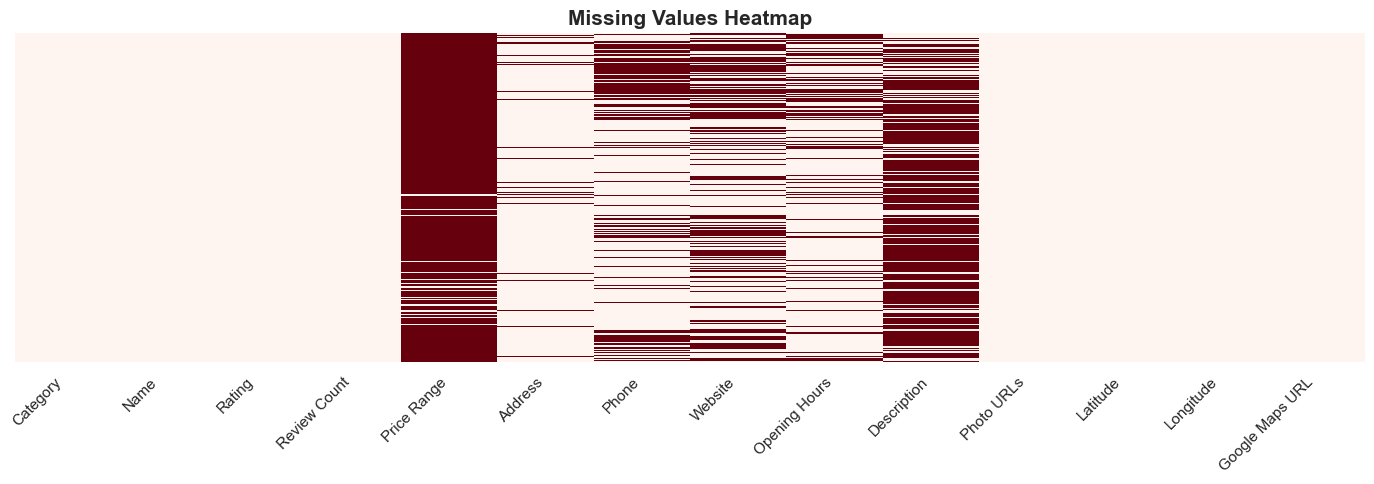

In [51]:
# ── 2. Missing Values Heatmap ──────────────────────────────────
plt.figure(figsize=(14, 5))
sns.heatmap(dff.isnull(), cbar=False, cmap='Reds', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values_heatmap.png', dpi=150)
plt.show()

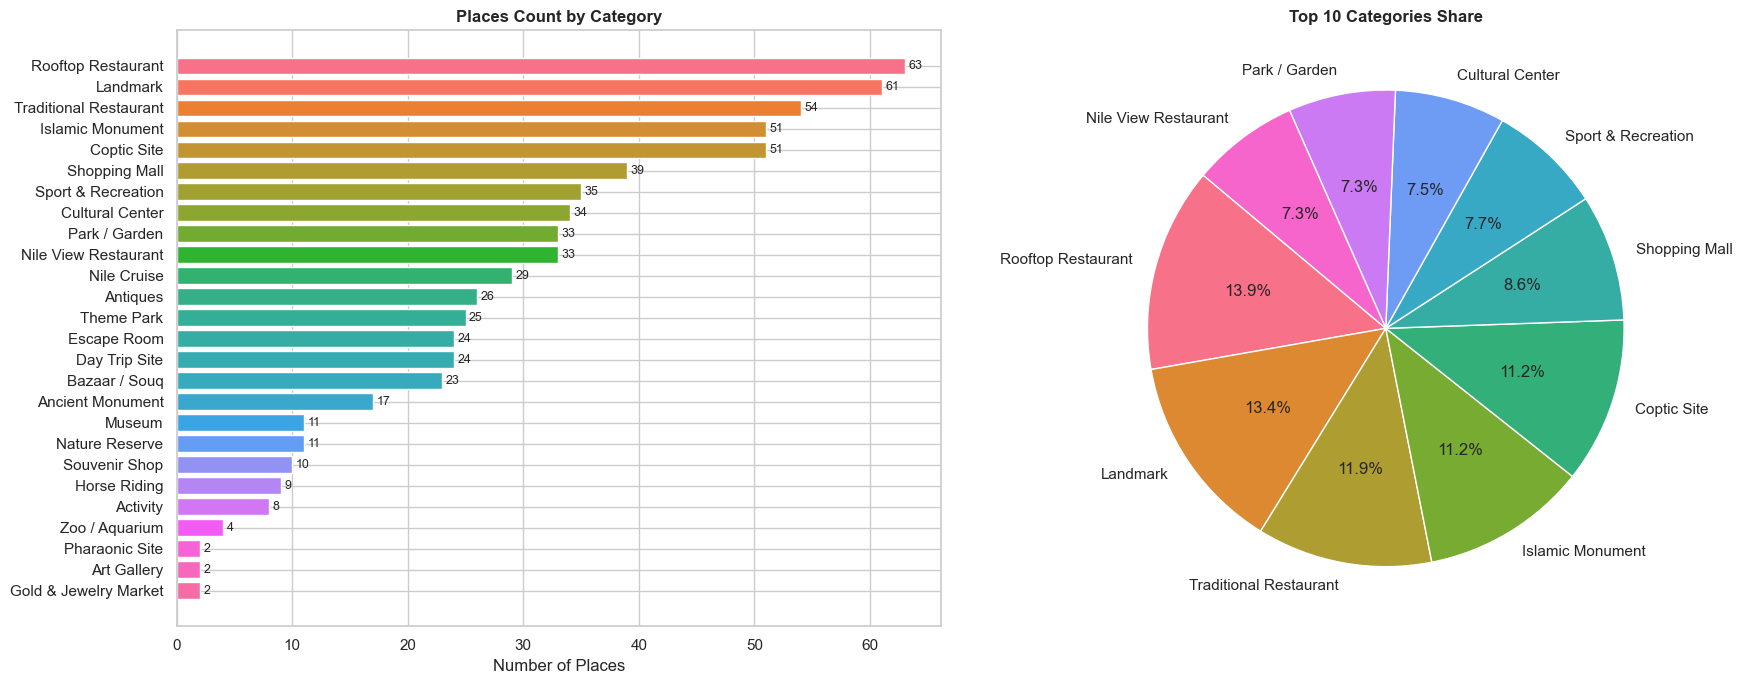

In [52]:
# ── 3. Category Distribution ───────────────────────────────────
cat_counts = dff['Category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart
bars = axes[0].barh(cat_counts.index, cat_counts.values, 
                     color=sns.color_palette('husl', len(cat_counts)))
axes[0].set_xlabel('Number of Places')
axes[0].set_title('Places Count by Category', fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
                 str(val), va='center', fontsize=9)

# Pie chart (top 10)
top10 = cat_counts.head(10)
axes[1].pie(top10.values, labels=top10.index, autopct='%1.1f%%', 
            colors=sns.color_palette('husl', 10), startangle=140)
axes[1].set_title('Top 10 Categories Share', fontweight='bold')

plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150)
plt.show()

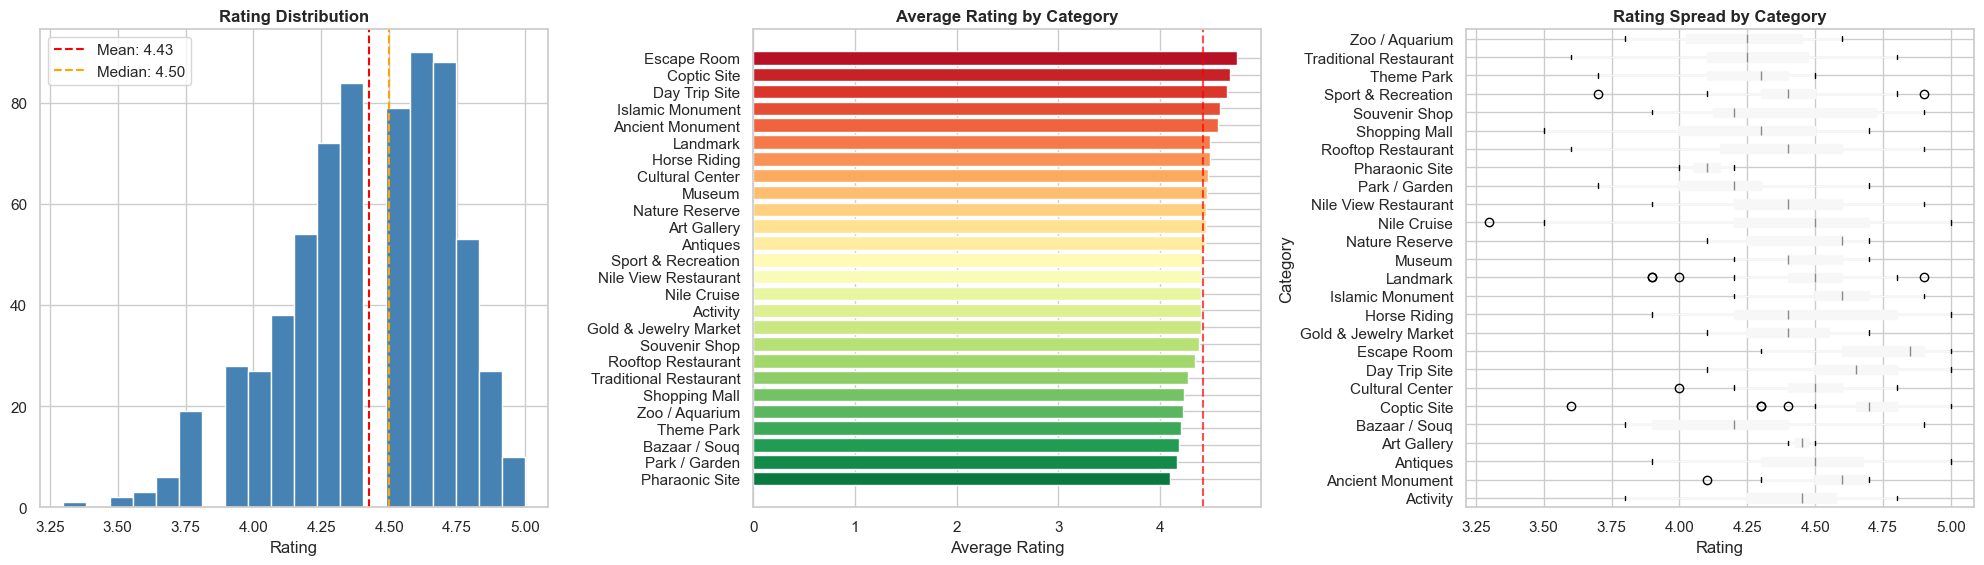

In [54]:
# ── 4. Rating Analysis ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribution
axes[0].hist(dff['Rating'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(dff['Rating'].mean(), color='red', linestyle='--', label=f"Mean: {dff['Rating'].mean():.2f}")
axes[0].axvline(dff['Rating'].median(), color='orange', linestyle='--', label=f"Median: {dff['Rating'].median():.2f}")
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].legend()

# Rating by Category (avg)
avg_rating = dff.groupby('Category')['Rating'].mean().sort_values(ascending=False)
axes[1].barh(avg_rating.index, avg_rating.values, 
             color=sns.color_palette('RdYlGn', len(avg_rating)))
axes[1].set_xlabel('Average Rating')
axes[1].set_title('Average Rating by Category', fontweight='bold')
axes[1].axvline(dff['Rating'].mean(), color='red', linestyle='--', alpha=0.7)
axes[1].invert_yaxis()

# Boxplot
dff.boxplot(column='Rating', by='Category', ax=axes[2], vert=False, 
            patch_artist=True)
axes[2].set_title('Rating Spread by Category', fontweight='bold')
axes[2].set_xlabel('Rating')
plt.suptitle('')

plt.tight_layout()
plt.savefig('rating_analysis.png', dpi=150)
plt.show()

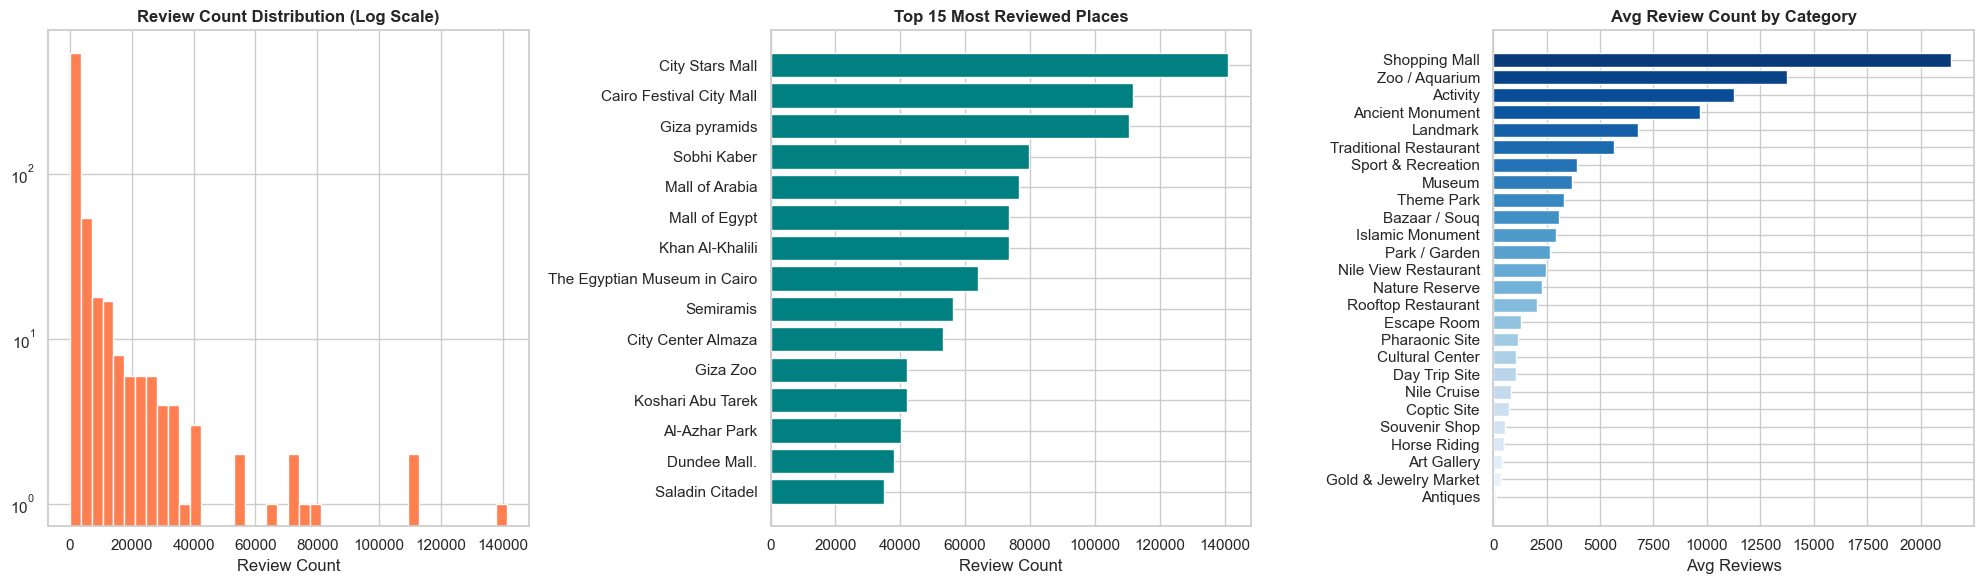

In [55]:
# ── 5. Review Count Analysis ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribution (log scale)
axes[0].hist(dff['Review Count'].dropna(), bins=40, color='coral', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Review Count Distribution (Log Scale)', fontweight='bold')
axes[0].set_xlabel('Review Count')

# Top 15 most reviewed places
top_reviewed = dff.nlargest(15, 'Review Count')[['Name', 'Review Count']]
axes[1].barh(top_reviewed['Name'], top_reviewed['Review Count'], color='teal')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Most Reviewed Places', fontweight='bold')
axes[1].set_xlabel('Review Count')

# Avg review count by category
avg_reviews = dff.groupby('Category')['Review Count'].mean().sort_values(ascending=False)
axes[2].barh(avg_reviews.index, avg_reviews.values, 
             color=sns.color_palette('Blues_r', len(avg_reviews)))
axes[2].invert_yaxis()
axes[2].set_title('Avg Review Count by Category', fontweight='bold')
axes[2].set_xlabel('Avg Reviews')

plt.tight_layout()
plt.savefig('review_count_analysis.png', dpi=150)
plt.show()

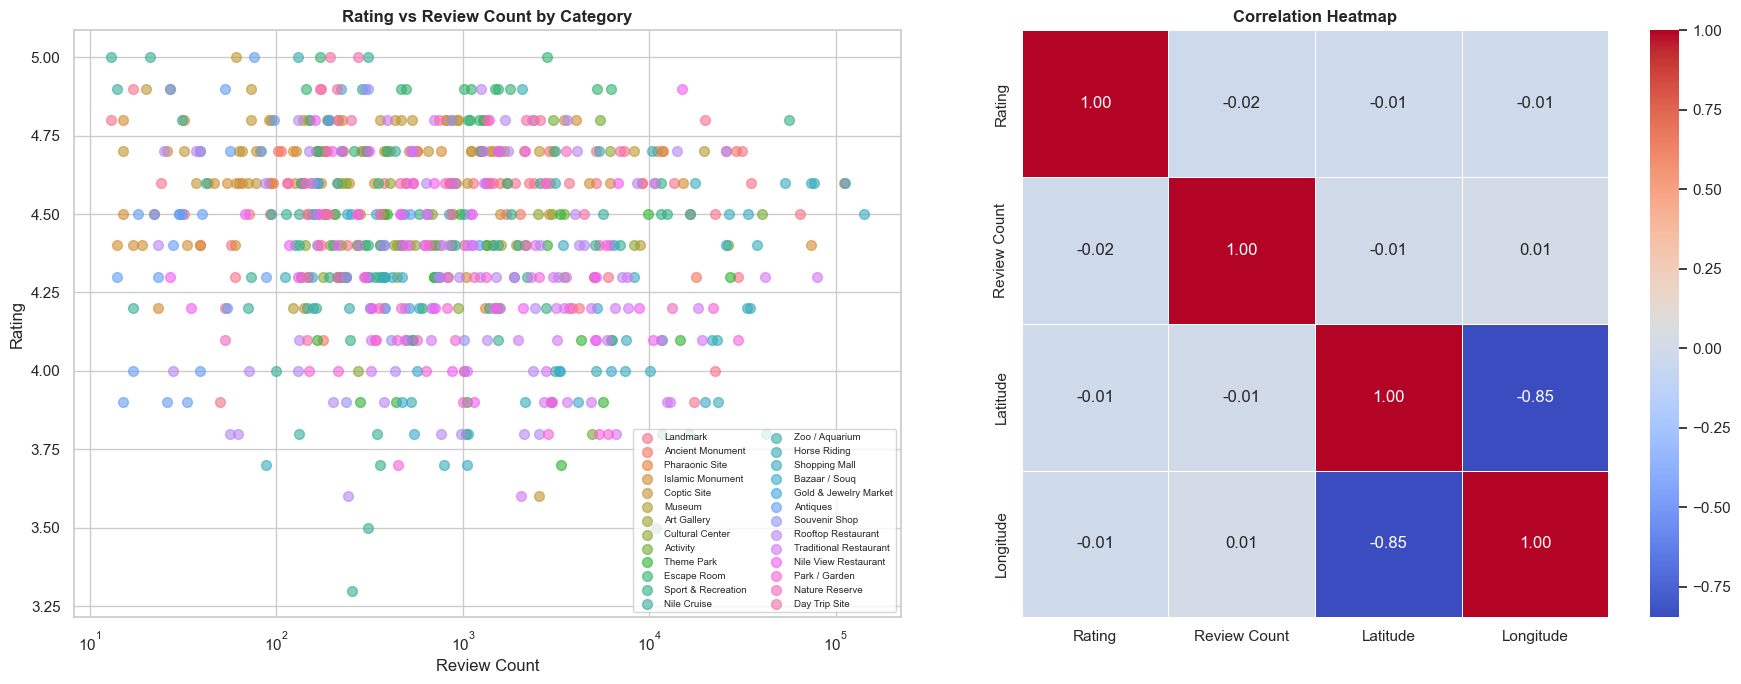

In [56]:
# ── 6. Rating vs Review Count (Scatter) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter by category
categories = dff['Category'].unique()
colors = sns.color_palette('husl', len(categories))
for cat, color in zip(categories, colors):
    subset = dff[dff['Category'] == cat]
    axes[0].scatter(subset['Review Count'], subset['Rating'], 
                    label=cat, alpha=0.6, s=50, color=color)
axes[0].set_xlabel('Review Count')
axes[0].set_ylabel('Rating')
axes[0].set_title('Rating vs Review Count by Category', fontweight='bold')
axes[0].legend(fontsize=7, ncol=2, loc='lower right')
axes[0].set_xscale('log')

# Correlation heatmap
corr = dff[['Rating', 'Review Count', 'Latitude', 'Longitude']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1], linewidths=0.5, square=True)
axes[1].set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('rating_vs_reviews.png', dpi=150)
plt.show()

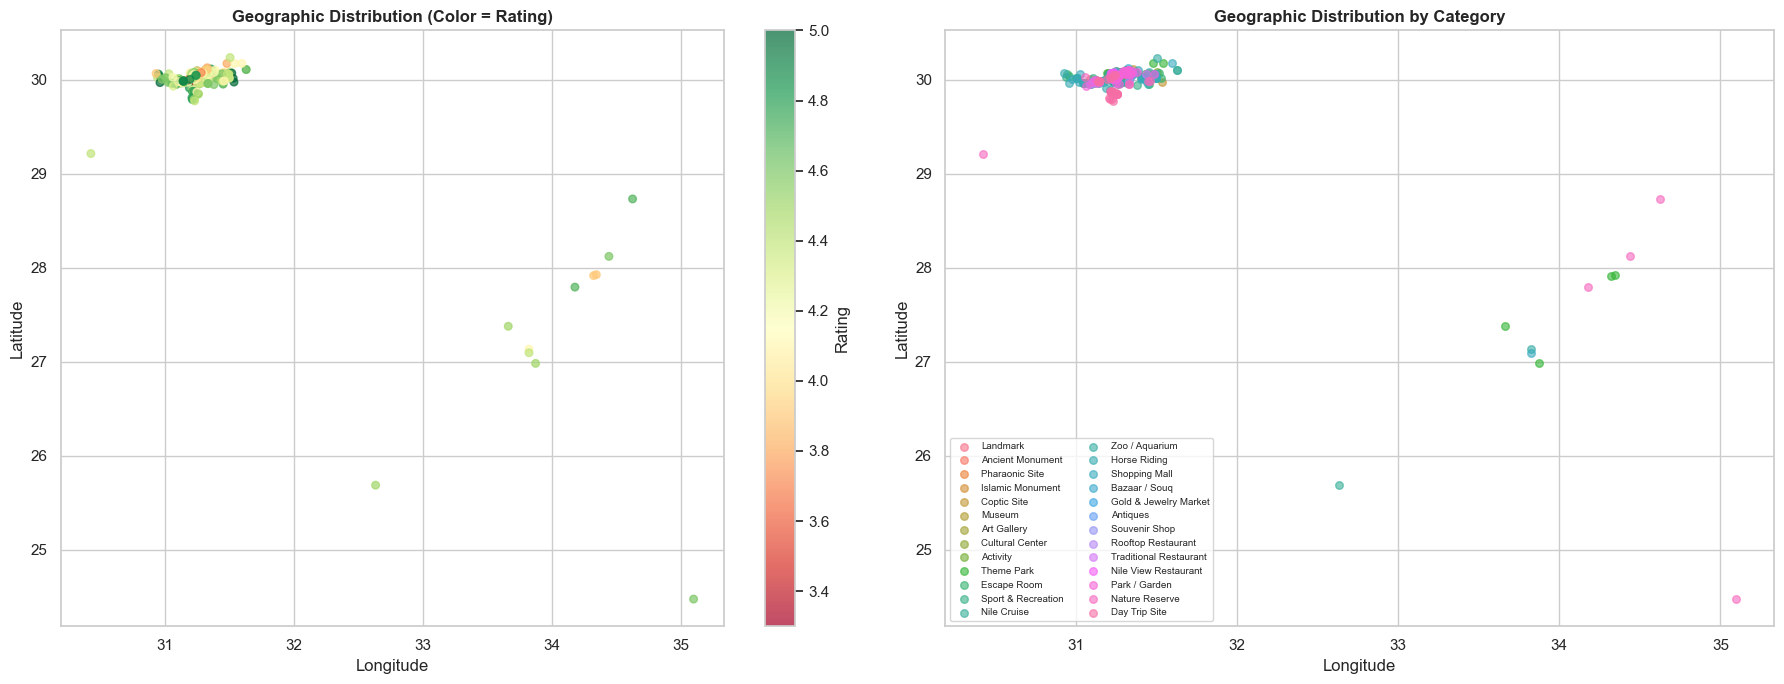

In [57]:
# ── 7. Geographic Distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# All places scatter map
sc = axes[0].scatter(dff['Longitude'], dff['Latitude'], 
                      c=dff['Rating'], cmap='RdYlGn', 
                      s=30, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Rating')
axes[0].set_title('Geographic Distribution (Color = Rating)', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# By category
for cat, color in zip(categories, colors):
    subset = dff[dff['Category'] == cat]
    axes[1].scatter(subset['Longitude'], subset['Latitude'], 
                    label=cat, alpha=0.6, s=30, color=color)
axes[1].set_title('Geographic Distribution by Category', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('geographic_distribution.png', dpi=150)
plt.show()

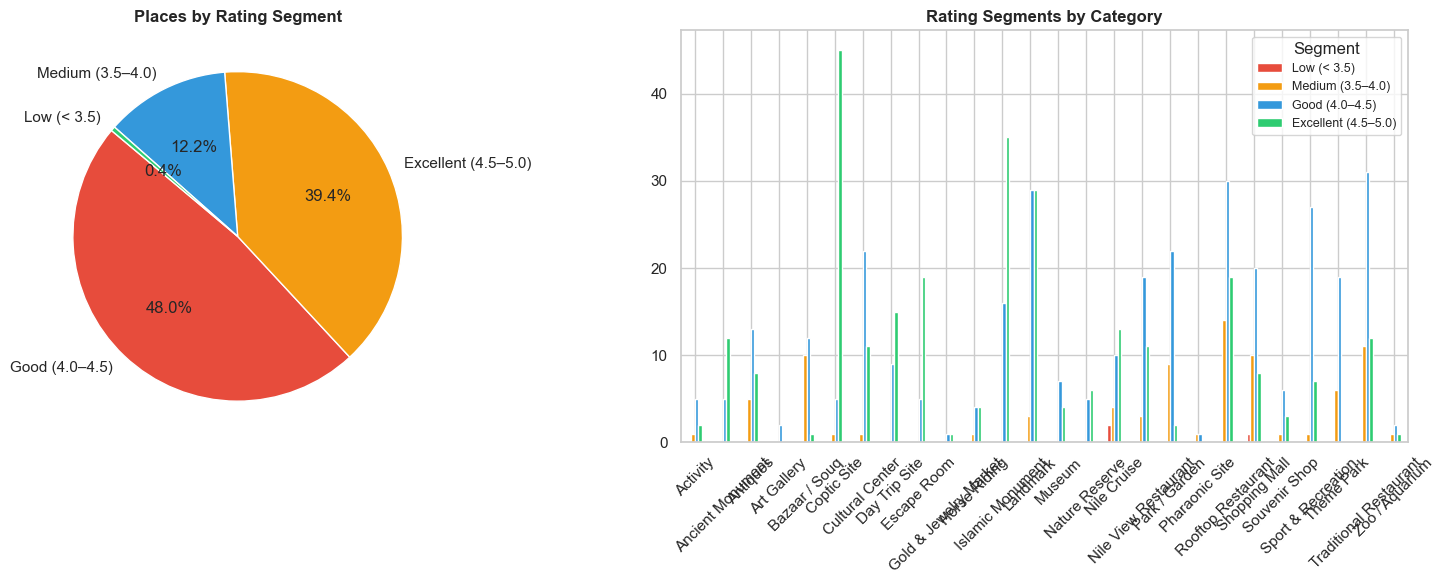


KEY INSIGHTS
Total Places         : 681
Total Categories     : 26
Avg Rating           : 4.43
Avg Review Count     : 4174
Most Common Category : Rooftop Restaurant
Highest Rated Place  : The Evangelist Coptic Orthodox Church, New Cairo (5.0)
Most Reviewed Place  : City Stars Mall (141192 reviews)
% Excellent Rating   : 51.0%


In [58]:
# ── 8. Rating Segments ─────────────────────────────────────────
dff['Rating_Segment'] = pd.cut(dff['Rating'], 
                                bins=[0, 3.5, 4.0, 4.5, 5.0],
                                labels=['Low (< 3.5)', 'Medium (3.5–4.0)', 
                                        'Good (4.0–4.5)', 'Excellent (4.5–5.0)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_counts = dff['Rating_Segment'].value_counts()
axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c','#f39c12','#3498db','#2ecc71'], startangle=140)
axes[0].set_title('Places by Rating Segment', fontweight='bold')

seg_cat = dff.groupby(['Category', 'Rating_Segment']).size().unstack(fill_value=0)
seg_cat.plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#3498db','#2ecc71'],
             edgecolor='white')
axes[1].set_title('Rating Segments by Category', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Segment', fontsize=9)

plt.tight_layout()
plt.savefig('rating_segments.png', dpi=150)
plt.show()

# ── Final Summary ──────────────────────────────────────────────
print("\n" + "=" * 50)
print("KEY INSIGHTS")
print("=" * 50)
print(f"Total Places         : {len(dff)}")
print(f"Total Categories     : {dff['Category'].nunique()}")
print(f"Avg Rating           : {dff['Rating'].mean():.2f}")
print(f"Avg Review Count     : {dff['Review Count'].mean():.0f}")
print(f"Most Common Category : {dff['Category'].value_counts().idxmax()}")
print(f"Highest Rated Place  : {dff.loc[dff['Rating'].idxmax(), 'Name']} ({dff['Rating'].max()})")
print(f"Most Reviewed Place  : {dff.loc[dff['Review Count'].idxmax(), 'Name']} ({int(dff['Review Count'].max())} reviews)")
print(f"% Excellent Rating   : {(dff['Rating'] >= 4.5).mean()*100:.1f}%")

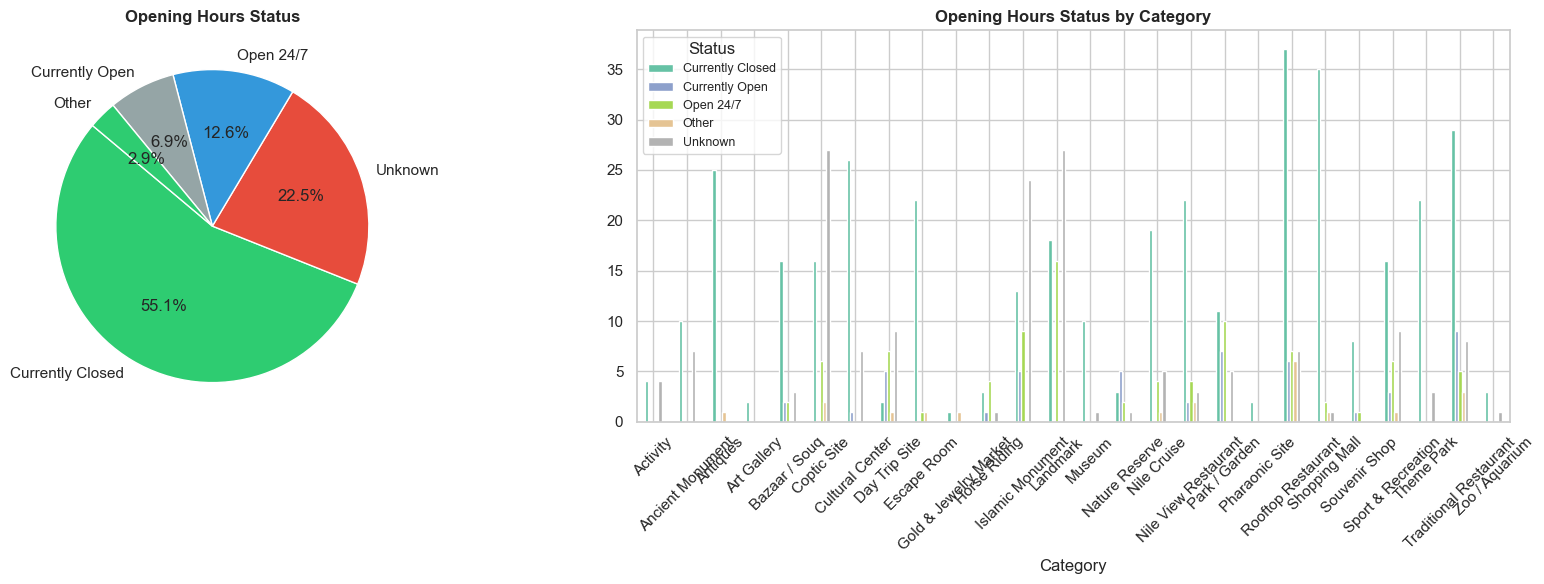

In [59]:
# ── 9. Opening Hours Analysis ──────────────────────────────────
# Classify opening hours
def classify_hours(text):
    if pd.isna(text): return 'Unknown'
    text = str(text).lower()
    if 'open around the clock' in text or '24' in text: return 'Open 24/7'
    if 'closed' in text: return 'Currently Closed'
    if 'open' in text: return 'Currently Open'
    return 'Other'

dff['Hours_Status'] = dff['Opening Hours'].apply(classify_hours)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Overall status
status_counts = dff['Hours_Status'].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#3498db', '#95a5a6'], startangle=140)
axes[0].set_title('Opening Hours Status', fontweight='bold')

# By category
hours_cat = dff.groupby(['Category', 'Hours_Status']).size().unstack(fill_value=0)
hours_cat.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Opening Hours Status by Category', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Status', fontsize=9)

plt.tight_layout()
plt.savefig('opening_hours.png', dpi=150)
plt.show()

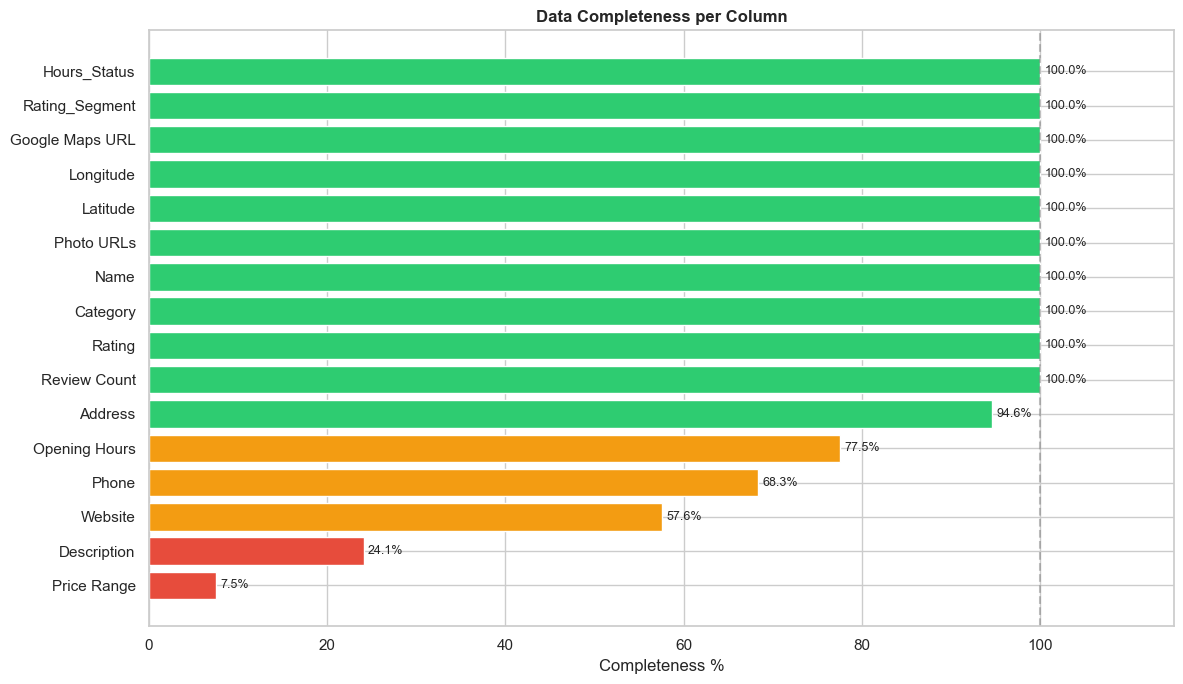

In [60]:
# ── 10. Data Completeness ──────────────────────────────────────
completeness = ((dff.notnull().sum() / len(dff)) * 100).sort_values()

colors = ['#e74c3c' if v < 50 else '#f39c12' if v < 80 else '#2ecc71' 
          for v in completeness.values]

plt.figure(figsize=(12, 7))
bars = plt.barh(completeness.index, completeness.values, color=colors)
plt.axvline(100, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Completeness %')
plt.title('Data Completeness per Column', fontweight='bold')
for bar, val in zip(bars, completeness.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
plt.xlim(0, 115)
plt.tight_layout()
plt.savefig('data_completeness.png', dpi=150)
plt.show()

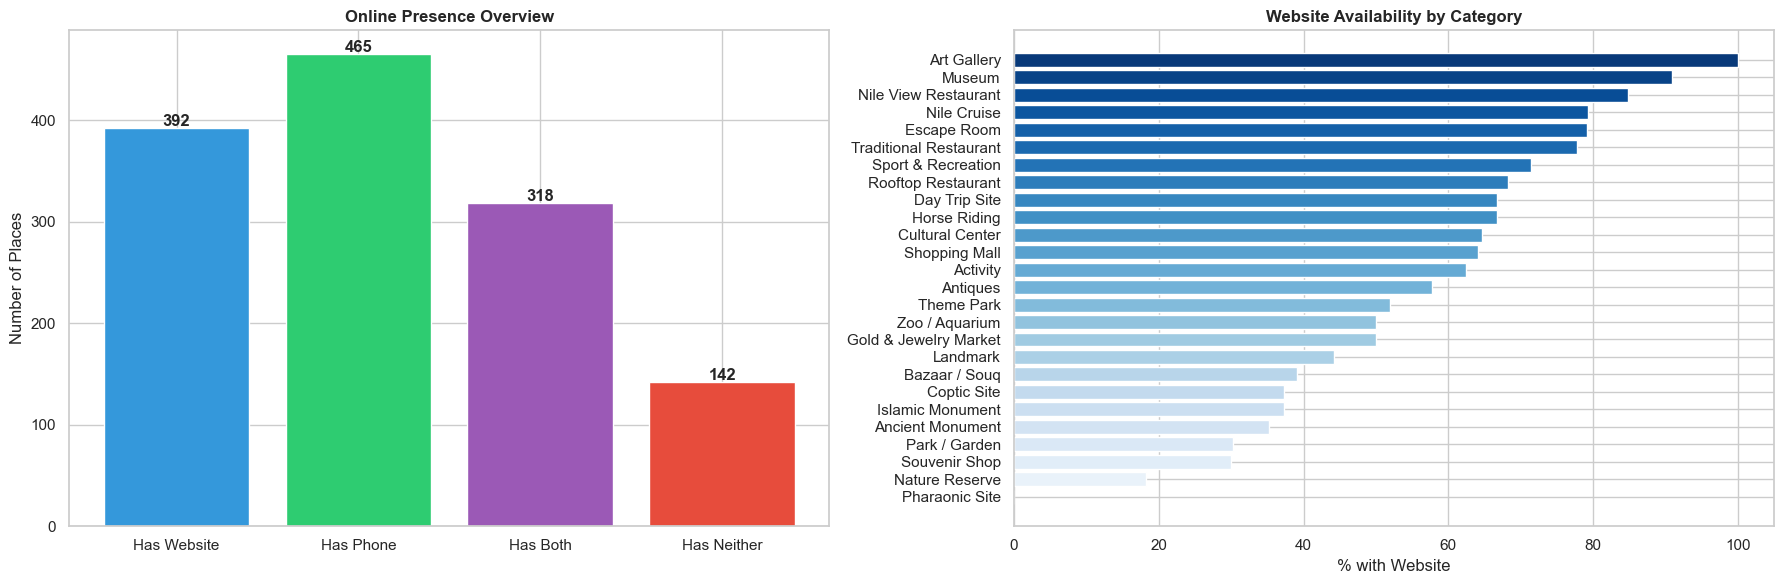

In [62]:
# ── 11. Online Presence Analysis ──────────────────────────────
dff['Has_Website'] = dff['Website'].notnull()
dff['Has_Phone']   = dff['Phone'].notnull()
dff['Has_Both']    = dff['Has_Website'] & dff['Has_Phone']
dff['Has_None']    = ~dff['Has_Website'] & ~dff['Has_Phone']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Overall online presence
presence = {
    'Has Website': dff['Has_Website'].sum(),
    'Has Phone'  : dff['Has_Phone'].sum(),
    'Has Both'   : dff['Has_Both'].sum(),
    'Has Neither': dff['Has_None'].sum()
}
axes[0].bar(presence.keys(), presence.values(), 
            color=['#3498db','#2ecc71','#9b59b6','#e74c3c'], edgecolor='white')
axes[0].set_title('Online Presence Overview', fontweight='bold')
axes[0].set_ylabel('Number of Places')
for i, (k, v) in enumerate(presence.items()):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# By category
website_cat = dff.groupby('Category')['Has_Website'].mean() * 100
website_cat = website_cat.sort_values(ascending=False)
axes[1].barh(website_cat.index, website_cat.values, 
             color=sns.color_palette('Blues_r', len(website_cat)))
axes[1].set_xlabel('% with Website')
axes[1].set_title('Website Availability by Category', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('online_presence.png', dpi=150)
plt.show()

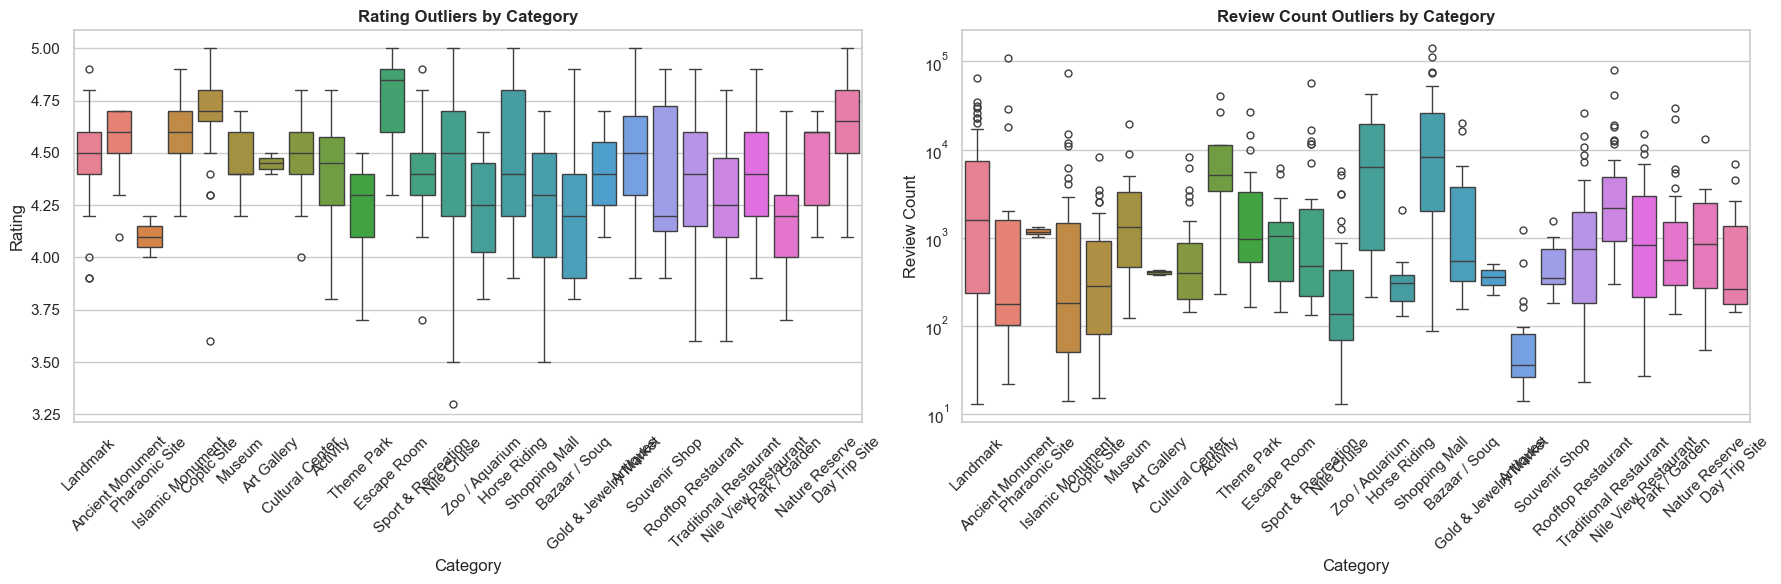

─── Outlier Count (IQR Method) ───
Rating: 1 outliers (0.1%)
Review Count: 91 outliers (13.4%)


In [63]:
# ── 12. Outlier Detection ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Rating outliers
sns.boxplot(data=dff, x='Category', y='Rating', ax=axes[0],
            palette='husl', flierprops=dict(marker='o', color='red', markersize=5))
axes[0].set_title('Rating Outliers by Category', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Review Count outliers
sns.boxplot(data=dff, x='Category', y='Review Count', ax=axes[1],
            palette='husl', flierprops=dict(marker='o', color='red', markersize=5))
axes[1].set_title('Review Count Outliers by Category', fontweight='bold')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outliers.png', dpi=150)
plt.show()

# Print outlier counts using IQR method
print("─── Outlier Count (IQR Method) ───")
for col in ['Rating', 'Review Count']:
    Q1 = dff[col].quantile(0.25)
    Q3 = dff[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = dff[(dff[col] < Q1 - 1.5*IQR) | (dff[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(dff)*100:.1f}%)")

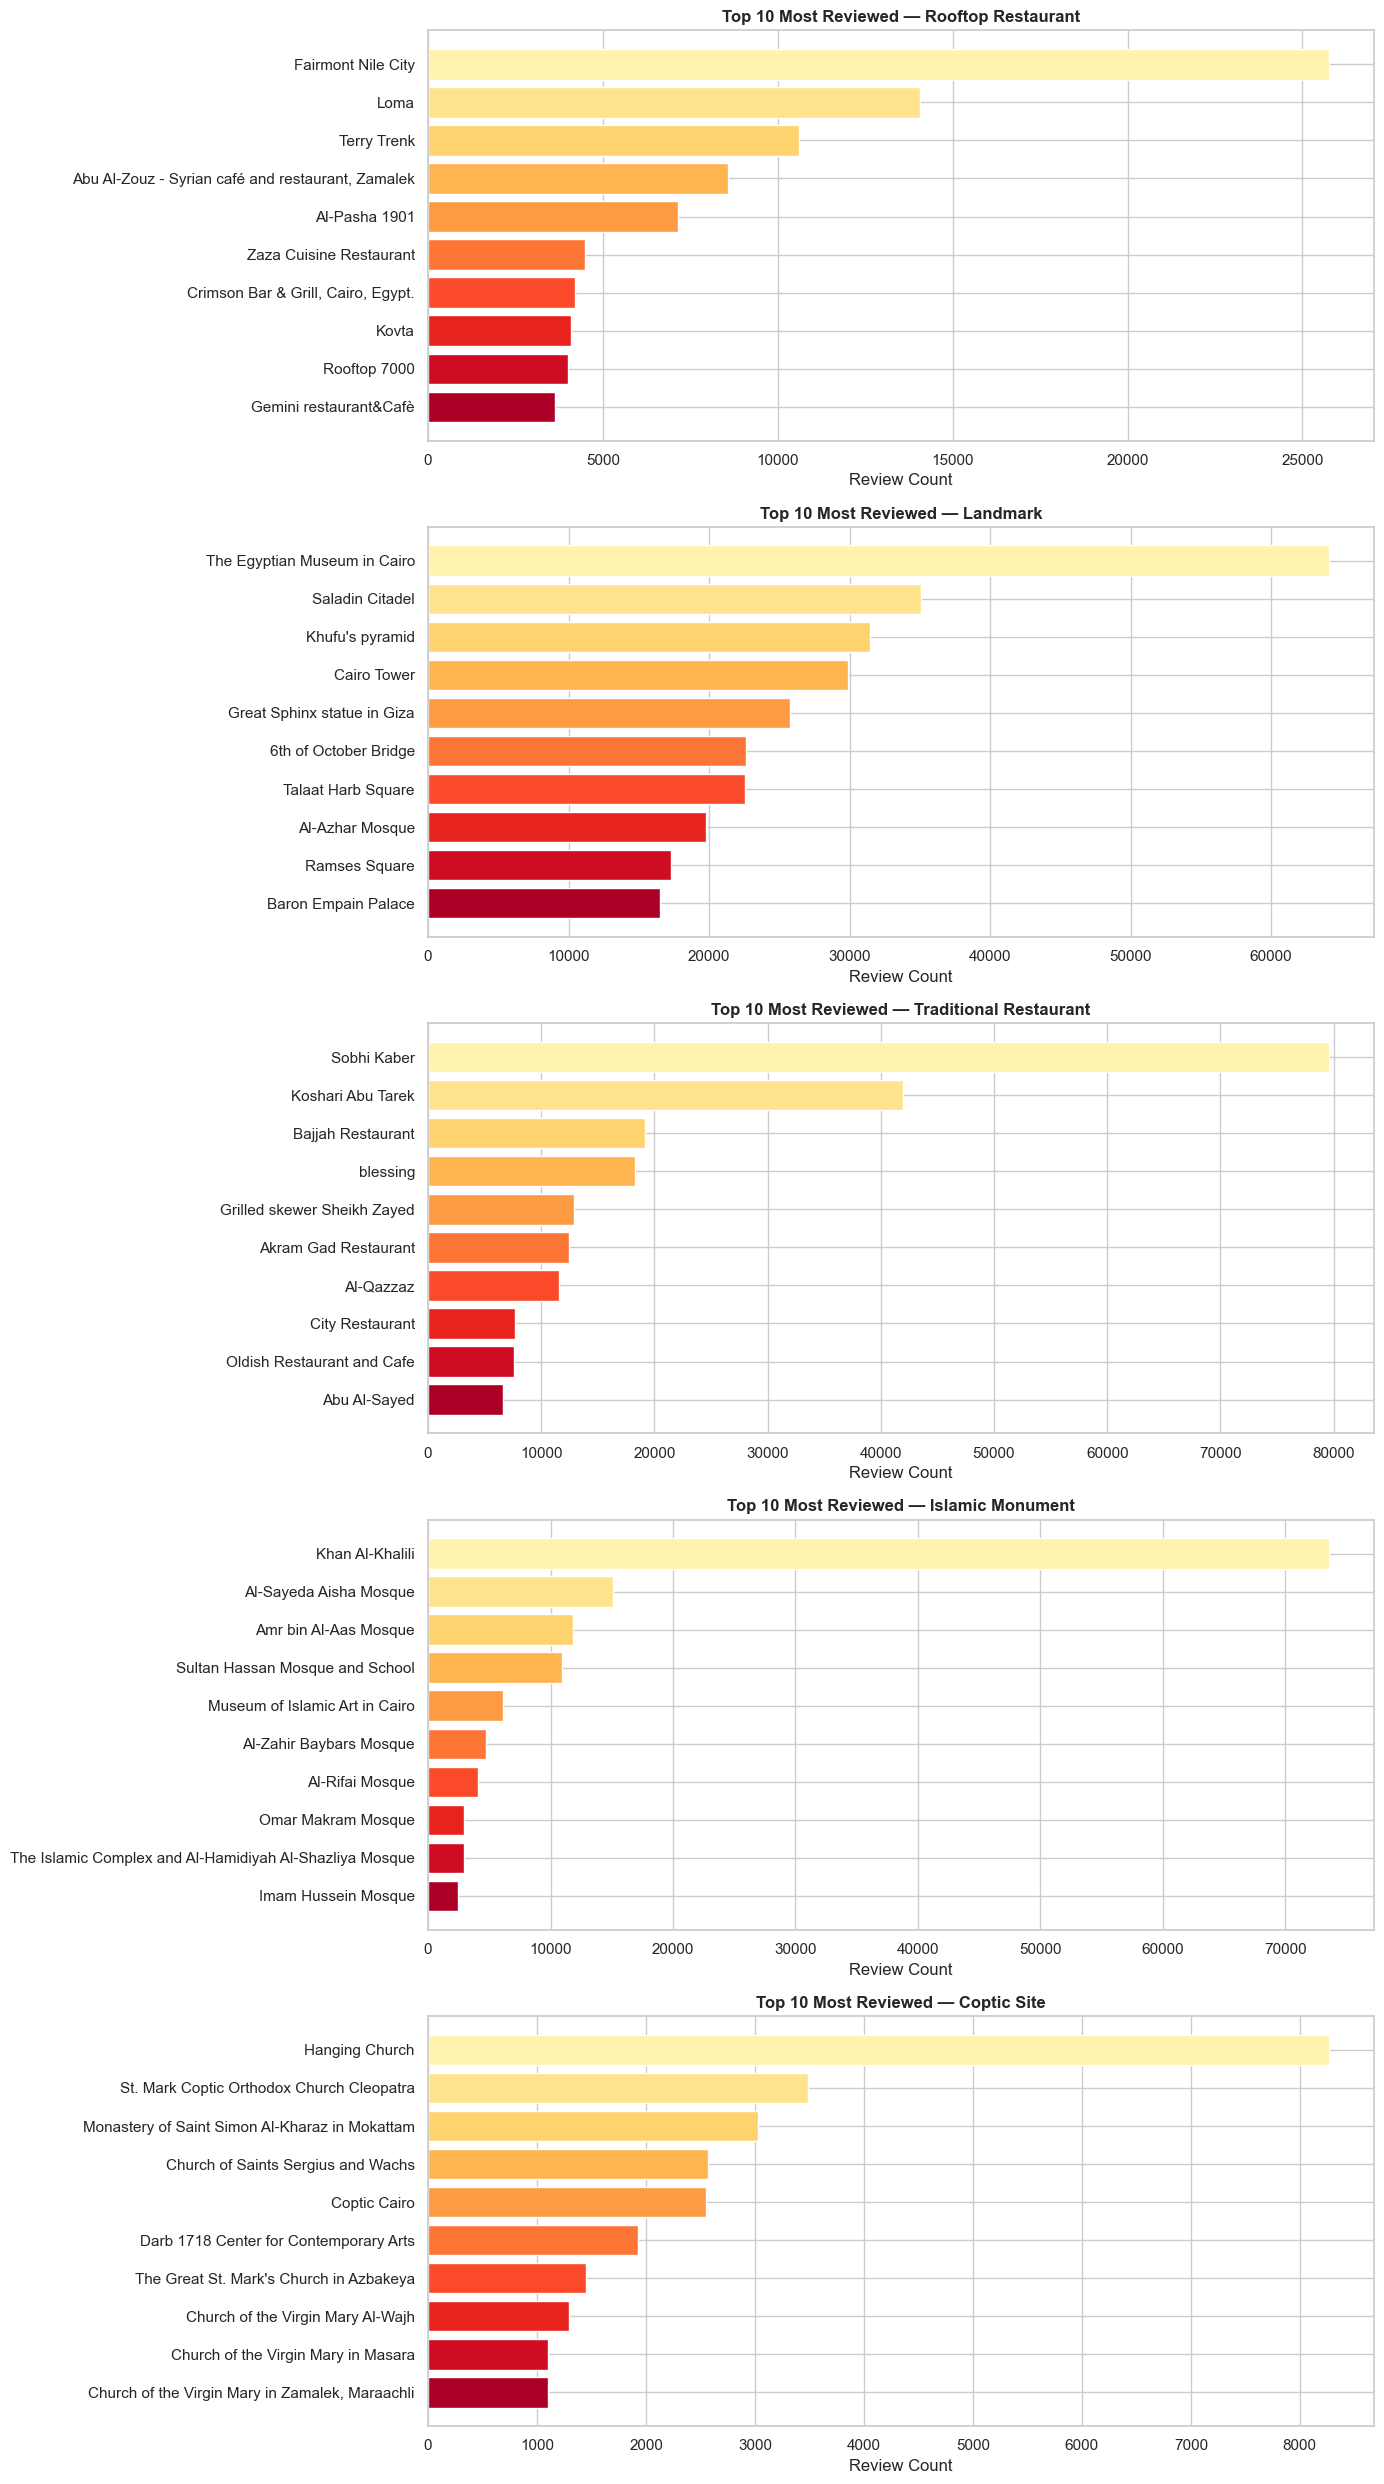

In [64]:
# ── 13. Top 10 Places per Category ────────────────────────────
categories_to_show = dff['Category'].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(len(categories_to_show), 1, 
                          figsize=(14, 5 * len(categories_to_show)))

for i, cat in enumerate(categories_to_show):
    subset = dff[dff['Category'] == cat].nlargest(10, 'Review Count')
    colors_bar = sns.color_palette('YlOrRd', len(subset))
    axes[i].barh(subset['Name'], subset['Review Count'], color=colors_bar)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top 10 Most Reviewed — {cat}', fontweight='bold')
    axes[i].set_xlabel('Review Count')

plt.tight_layout()
plt.savefig('top10_per_category.png', dpi=150)
plt.show()

In [66]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


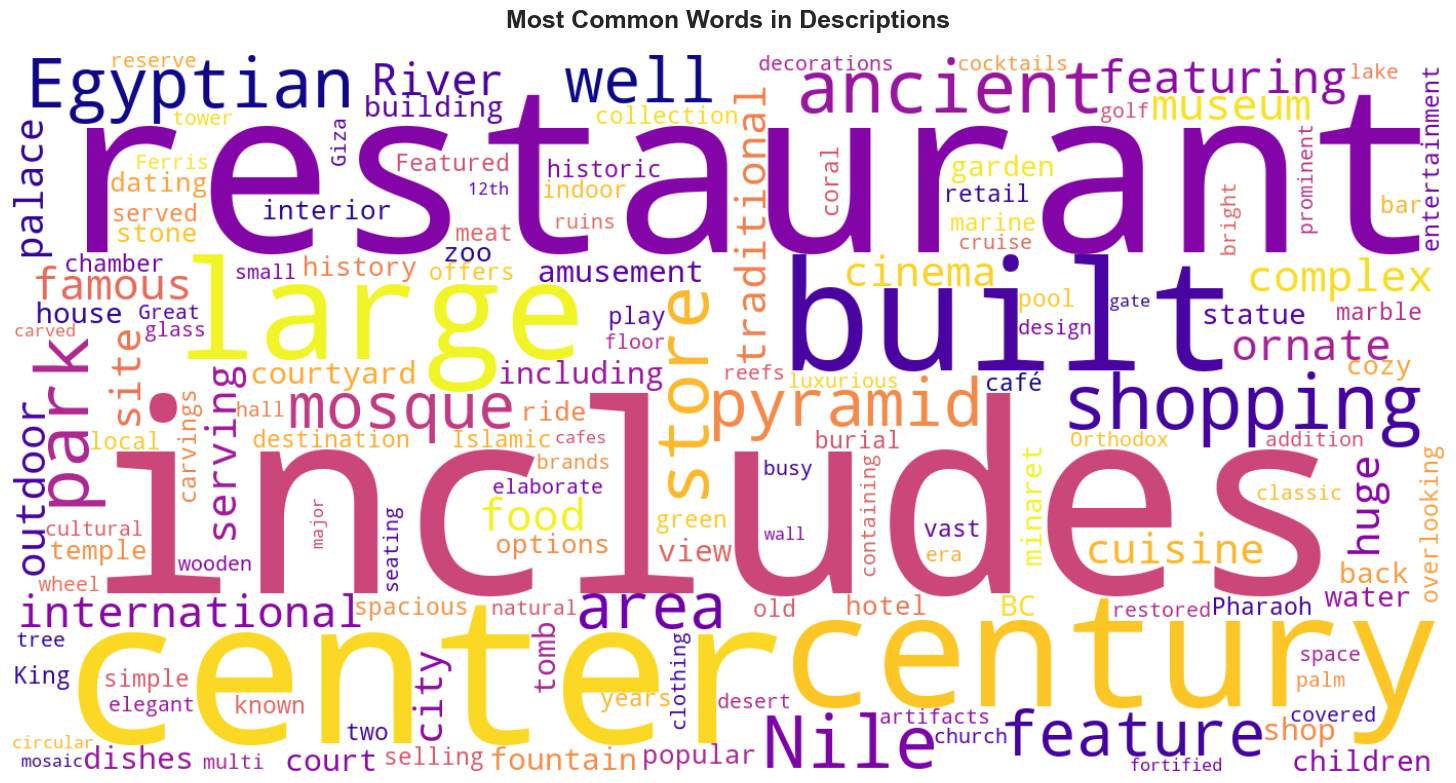

In [67]:
# ── 14. Word Cloud from Descriptions ──────────────────────────
# pip install wordcloud
from wordcloud import WordCloud, STOPWORDS

text = ' '.join(dff['Description'].dropna().tolist())

stopwords = set(STOPWORDS)
stopwords.update(['Add', 'phone', 'number', 'place', 'Cairo', 'located'])

wordcloud = WordCloud(
    width=1400, height=700,
    background_color='white',
    stopwords=stopwords,
    colormap='plasma',
    max_words=150,
    collocations=False
).generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Descriptions', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

# Add pricing 

In [8]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
data_with_p = pd.read_excel(r"H:\Work\RunningWork\grad\landmarks\prices.xlsx")

In [7]:
data_with_p

,Name,Category,Local Price (EGP)
0,Cairo Tower,Archaeological Site,550-750
1,Talaat Harb Square,Square/Landmark,150-260
2,Tahrir Square,Square/Landmark,120-220
3,Bab Zuwila,Palace/Historic Site,300-440
4,Saladin Citadel (full complex),Archaeological Site,700-1050
...,...,...,...
661,J&G Steakhouse Cairo,Restaurant/Café,700-1300
662,Abd El Wahab Restaurant – Zamalek,Restaurant/Café,500-930
663,Sea Gel,Restaurant/Café,450-840
664,Happy Dolphin Restaurant,Restaurant/Café,450-840


In [4]:
data_with_nop = pd.read_csv("H:\\Work\\RunningWork\\grad\\landmarks\\Cairo_Tourist_Attractions_Final.csv")

In [6]:
data_with_nop

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,Landmark,Cairo Tower,4.3,29908.0,NaN,"\nQasr El Nil Street, Zamalek, Cairo Governor...",2.273651e+08,NaN,Closed · Opens at 9am,A lotus-shaped tower covered with 8 million mo...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...
1,Landmark,Talaat Harb Square,4.5,22548.0,NaN,"\nTalaat Harb Street, Bab El Louk, Qasr El Ni...",NaN,NaN,Open around the clock,A major intersection featuring a statue bearin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...
2,Landmark,Tahrir Square,4.6,5206.0,NaN,"\nTahrir Square, Sadat Station, Qasr El Nil D...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...
3,Landmark,Bab Zuwila,4.7,2895.0,NaN,"\n27V5+545, Muhammad Ali, Al-Darb Al-Ahmar, C...",NaN,https://www.archnet.org/sites/2728,Open around the clock,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...
4,Landmark,Saladin Citadel,4.6,35069.0,NaN,NaN,2.251217e+08,https://egymonuments.gov.eg/ar/archaeological-...,NaN,An imposing fortress and wall built by Saladin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,Day Trip Site,Egypt time travel,4.9,174.0,NaN,"\n21 Studio, Al Haram, Giza Governorate 12511",1.028003e+09,https://www.egypttimetravel.com/,Friday\nWe work 24 hours a day Saturday\nWe wo...,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.003267,31.190765,https://www.google.com/maps/place/Egypt+time+t...
677,Day Trip Site,Black pyramid,4.5,190.0,NaN,"\nQ6RF+MGX, Al Marazeek - Dahshour, desert ba...",NaN,NaN,NaN,The ruins of an ancient pyramid containing bur...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.791747,31.223859,https://www.google.com/maps/place/%D8%A7%D9%84...
678,Day Trip Site,Ramses II Red Granite Statue,4.5,181.0,NaN,"\nR7X3+QQM, Mit Rahina, Badrashin Center, Giz...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.849465,31.254411,https://www.google.com/maps/place/Ramses+II+Re...
679,Day Trip Site,Cairo Top Tours,4.9,211.0,NaN,"\n3.st El Lewa Hassan Said Mashaal, Pyramids ...",1.022773e+09,https://www.cairotoptours.com/,Closed · Opens on Saturdays at 12 am,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.986096,31.137571,https://www.google.com/maps/place/Cairo+Top+To...


In [8]:
duplicates_count = data_with_nop["Name"].duplicated().sum()
print(duplicates_count)

2


In [9]:
data_with_nop[data_with_nop["Name"].duplicated(keep=False)]

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
13,Landmark,The wall of the stream of eyes,4.4,519.0,NaN,"\n26CJ+R4W, Magra Al Eyoon, Foum Al Khaleej a...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.022114,31.230314,https://www.google.com/maps/place/%D8%B3%D9%88...
124,Islamic Monument,The wall of the stream of eyes,4.3,1035.0,NaN,"\n2792+5FV, Ain El-Sira, Old Cairo District, ...",NaN,NaN,Open around the clock,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.017993,31.251166,https://www.google.com/maps/place/%D8%B3%D9%88...
466,Rooftop Restaurant,The Rooftop,4.4,164.0,NaN,"\nAhmed Ragheb, Qasr al-Nil District, Cairo G...",2.279800e+08,https://www.kempinski.com/en/nile-hotel/restau...,Closed · Opens at 9am,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.038680,31.230588,https://www.google.com/maps/place/%D8%B0%D8%A7...
471,Rooftop Restaurant,The Rooftop,3.8,62.0,NaN,"\nMarvel Stone Hotel, 6 gerier street Inside,...",1.127696e+09,https://rooftoprestaurant.org/,Open · Closes at 11:30 PM,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.975074,31.141668,https://www.google.com/maps/place/The+Rooftop/...


In [10]:
duplicates = data_with_nop[data_with_nop["Name"].duplicated(keep=False)]
print(duplicates.sort_values("Name"))

               Category                            Name  Rating  Review Count  \
466  Rooftop Restaurant                     The Rooftop     4.4         164.0   
471  Rooftop Restaurant                     The Rooftop     3.8          62.0   
13             Landmark  The wall of the stream of eyes     4.4         519.0   
124    Islamic Monument  The wall of the stream of eyes     4.3        1035.0   

    Price Range                                            Address  \
466         NaN  \nAhmed Ragheb, Qasr al-Nil District, Cairo G...   
471         NaN  \nMarvel Stone Hotel, 6 gerier street Inside,...   
13          NaN  \n26CJ+R4W, Magra Al Eyoon, Foum Al Khaleej a...   
124         NaN  \n2792+5FV, Ain El-Sira, Old Cairo District, ...   

            Phone                                            Website  \
466  2.279800e+08  https://www.kempinski.com/en/nile-hotel/restau...   
471  1.127696e+09                     https://rooftoprestaurant.org/   
13            NaN          

In [11]:
data_with_nop = data_with_nop.drop_duplicates(subset="Name", keep="first")

In [12]:
data_with_nop = data_with_nop.drop_duplicates(subset="Name", keep="first")

In [13]:
data_with_nop[data_with_nop["Name"].duplicated(keep=False)]

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL


In [14]:
data_with_nop.shape

(679, 14)

In [18]:
import numpy as np

data_with_nop["Price Range"] = np.nan

In [19]:
data_with_nop

,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,Landmark,Cairo Tower,4.3,29908.0,NaN,"\nQasr El Nil Street, Zamalek, Cairo Governor...",2.273651e+08,NaN,Closed · Opens at 9am,A lotus-shaped tower covered with 8 million mo...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...
1,Landmark,Talaat Harb Square,4.5,22548.0,NaN,"\nTalaat Harb Street, Bab El Louk, Qasr El Ni...",NaN,NaN,Open around the clock,A major intersection featuring a statue bearin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...
2,Landmark,Tahrir Square,4.6,5206.0,NaN,"\nTahrir Square, Sadat Station, Qasr El Nil D...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...
3,Landmark,Bab Zuwila,4.7,2895.0,NaN,"\n27V5+545, Muhammad Ali, Al-Darb Al-Ahmar, C...",NaN,https://www.archnet.org/sites/2728,Open around the clock,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...
4,Landmark,Saladin Citadel,4.6,35069.0,NaN,NaN,2.251217e+08,https://egymonuments.gov.eg/ar/archaeological-...,NaN,An imposing fortress and wall built by Saladin...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,Day Trip Site,Egypt time travel,4.9,174.0,NaN,"\n21 Studio, Al Haram, Giza Governorate 12511",1.028003e+09,https://www.egypttimetravel.com/,Friday\nWe work 24 hours a day Saturday\nWe wo...,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.003267,31.190765,https://www.google.com/maps/place/Egypt+time+t...
677,Day Trip Site,Black pyramid,4.5,190.0,NaN,"\nQ6RF+MGX, Al Marazeek - Dahshour, desert ba...",NaN,NaN,NaN,The ruins of an ancient pyramid containing bur...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.791747,31.223859,https://www.google.com/maps/place/%D8%A7%D9%84...
678,Day Trip Site,Ramses II Red Granite Statue,4.5,181.0,NaN,"\nR7X3+QQM, Mit Rahina, Badrashin Center, Giz...",NaN,NaN,NaN,Add the phone number to the place,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.849465,31.254411,https://www.google.com/maps/place/Ramses+II+Re...
679,Day Trip Site,Cairo Top Tours,4.9,211.0,NaN,"\n3.st El Lewa Hassan Said Mashaal, Pyramids ...",1.022773e+09,https://www.cairotoptours.com/,Closed · Opens on Saturdays at 12 am,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,29.986096,31.137571,https://www.google.com/maps/place/Cairo+Top+To...


In [20]:
common_names = set(data_with_nop["Name"]).intersection(set(data_with_p["Name"]))
count_common = len(common_names)

print(count_common)

401


,Name,Category,Local Price (EGP)


In [23]:
# Normalize both sides and compare
nop_names = data_with_nop["Name"].str.strip().str.lower()
p_names   = data_with_p["Name"].str.strip().str.lower()

# How many unique names in each?
print("Unique in nop:", nop_names.nunique())
print("Unique in p:  ", p_names.nunique())

# How many match after normalization?
print("Matches after strip+lower:", nop_names.isin(p_names).sum())

# Find names in p that DON'T appear in nop
missing = p_names[~p_names.isin(nop_names)]
print("Unmatched names from p_df:\n", missing.value_counts())

Unique in nop: 679
Unique in p:   666
Matches after strip+lower: 465
Unmatched names from p_df:
 Name
saladin citadel (full complex)         1
qasr el nil bridge                     1
prince muhammad ali palace – manial    1
al-muizz street (al moez street)       1
wall of the stream of eyes             1
                                      ..
bent el-sultan nile lounge             1
dalida cuisine – zamalek               1
cafe pro's – nile lounge               1
nile view – zamalek                    1
abd el wahab restaurant – zamalek      1
Name: count, Length: 201, dtype: int64


In [24]:
pip install thefuzz python-Levenshtein

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------------- ------------ 1.0/1.5 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.2 MB/s  0:00:00

   ---------------------------------------- 0/4 [rapidfuzz]
   ---------------------------------------- 0/4 [rapidfuzz]
   ---------------------------------------- 0/4 [rapidfuzz]
   ---------- ----------------------------- 1/4 [thefuzz]
   ---------------------------------------- 4/4 [python-Levenshtein]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from thefuzz import process
import pandas as pd

nop_names_clean = data_with_nop["Name"].str.strip().str.lower()
p_names_clean   = data_with_p["Name"].str.strip().str.lower()

# Get the 201 unmatched names from p
unmatched = p_names_clean[~p_names_clean.isin(nop_names_clean)].unique()

# Find closest match in nop for each unmatched name
results = []
for name in unmatched:
    match, score = process.extractOne(name, nop_names_clean.unique())
    results.append({"p_name": name, "closest_nop_name": match, "score": score})

fuzzy_df = pd.DataFrame(results).sort_values("score", ascending=False)
print(fuzzy_df.to_string())

In [25]:
from thefuzz import process
import pandas as pd

# Step 1: Normalize names in both dfs
data_with_nop["Name_clean"] = data_with_nop["Name"].str.strip().str.lower()
data_with_p["Name_clean"]   = data_with_p["Name"].str.strip().str.lower()

# Step 2: For each name in data_with_p, find the best match in data_with_nop
nop_clean_names = data_with_nop["Name_clean"].unique()

mapping = []
for _, row in data_with_p.iterrows():
    match, score = process.extractOne(row["Name_clean"], nop_clean_names)
    mapping.append({
        "Name_clean_p":   row["Name_clean"],
        "Name_clean_nop": match,
        "Price":          row["Local Price (EGP)"],
        "score":          score
    })

mapping_df = pd.DataFrame(mapping)

# Step 3: Merge mapping into data_with_nop
data_with_nop = data_with_nop.merge(
    mapping_df[["Name_clean_nop", "Price"]],
    left_on="Name_clean",
    right_on="Name_clean_nop",
    how="left"
)

# Step 4: Fill Price Range and clean up
data_with_nop["Price Range"] = data_with_nop["Price"]
data_with_nop.drop(columns=["Name_clean", "Name_clean_nop", "Price"], inplace=True)

print(data_with_nop[["Name", "Price Range"]].head(20))
print("Filled:", data_with_nop["Price Range"].notna().sum(), "/ 679")

                                     Name Price Range
0                             Cairo Tower     550-750
1                      Talaat Harb Square     150-260
2                           Tahrir Square     120-220
3                              Bab Zuwila     300-440
4                         Saladin Citadel    700-1050
5               Qasr El Nil Bridge statue     110-210
6                            Victory Gate     140-260
7                            Bab Al-Futuh     140-260
8                            Bab Al-Futuh     520-760
9                            Bab Al-Futuh    640-1000
10   Prince Muhammad Ali Palace in Manial     530-760
11            Habib Pasha Sakakini Palace     420-600
12  Al-Muizz Lidin Allah Al-Fatimi Street         NaN
13                      Prince Taz Palace     360-530
14                   Abdeen Palace Museum     470-650
15         The wall of the stream of eyes     100-210
16         The wall of the stream of eyes     130-260
17         The wall of the s

In [26]:
# 1. How many rows got filled vs still empty?
filled   = data_with_nop["Price Range"].notna().sum()
empty    = data_with_nop["Price Range"].isna().sum()
print(f"Filled: {filled} | Still empty: {empty}")

# 2. Check the 13 names that didn't get a price (expected)
no_price = data_with_nop[data_with_nop["Price Range"].isna()]["Name"]
print("\nNames with no price:\n", no_price.values)

# 3. Spot-check — pick a few names from data_with_p and verify the price transferred correctly
spot_check = data_with_p.sample(5)[["Name", "Local Price (EGP)"]]
for _, row in spot_check.iterrows():
    name = row["Name"]
    expected_price = row["Local Price (EGP)"]
    actual_price = data_with_nop[data_with_nop["Name"].str.strip().str.lower() == name.strip().lower()]["Price Range"].values
    print(f"\n'{name}'\n  Expected: {expected_price} | Got: {actual_price}")

# 4. Make sure no duplicate rows were created (should still be 679)
print("\nTotal rows:", len(data_with_nop), "(expected 679)")

# 5. Sanity check — price distribution looks reasonable?
print("\nPrice Range value counts:\n", data_with_nop["Price Range"].value_counts().head(10))

Filled: 666 | Still empty: 31

Names with no price:
 ['Al-Muizz Lidin Allah Al-Fatimi Street' 'Pyramid of Menkau Ra'
 'Пирамида царицы Меритетис I' 'Al Moez Street; Islamic Cairo'
 'Aq Sanqar Al-Salari Mosque (Blue Mosque)' 'Lőmä Lőmä'
 'The Church of the Great Martyrs Ben Abakir and John in ancient Egypt. The churches of ancient Egypt, Al-Manial, and Foum Al-Khaleej'
 'The Church of the Martyr Abi Seifin and the Martyr Demiana in the Boulaqia Canal, the churches of North Shubra'
 'The Church of the Great Martyrs St. George and Bashnouna in Foum el-Khaleej. The churches of ancient Egypt, Al-Manial and Foum El-Khaleej.'
 'Church of the Martyr Abo Sefein and Bishop, headquarters of the First Settlement - Church of Martyr Abo Sefein and Ava Makar'
 'Church of the Venerable Archangel Michael - Monastery of the Bahri Angel'
 'Goethe Institute Cairo - German Cultural Center'
 'French Institute in Egypt, Heliopolis branch' 'Saqqara Antiquities Area'
 'Hollywood Sharm El Sheikh' 'Makadi Water 

In [27]:
from thefuzz import process

# Step 1: Normalize
data_with_nop["Name_clean"] = data_with_nop["Name"].str.strip().str.lower()
data_with_p["Name_clean"]   = data_with_p["Name"].str.strip().str.lower()

nop_clean_names = data_with_nop["Name_clean"].tolist()

# Step 2: Build price lookup from data_with_p
price_lookup = dict(zip(data_with_p["Name_clean"], data_with_p["Local Price (EGP)"]))

# Step 3: For each row in data_with_nop, find best fuzzy match and assign price directly
for idx, row in data_with_nop.iterrows():
    match, score = process.extractOne(row["Name_clean"], price_lookup.keys())
    if score >= 80:
        data_with_nop.at[idx, "Price Range"] = price_lookup[match]

# Step 4: Clean up helper column
data_with_nop.drop(columns=["Name_clean"], inplace=True)

# Evaluate
print(f"Total rows : {len(data_with_nop)} (expected 679)")
print(f"Filled     : {data_with_nop['Price Range'].notna().sum()}")
print(f"Still empty: {data_with_nop['Price Range'].isna().sum()}")

Total rows : 697 (expected 679)
Filled     : 693
Still empty: 4


In [28]:
# Reload your original data
data_with_nop = pd.read_csv("H:\\Work\\RunningWork\\grad\\landmarks\\Cairo_Tourist_Attractions_Final.csv")  # or however you originally loaded it

# Then run the new code fresh
from thefuzz import process

data_with_nop["Name_clean"] = data_with_nop["Name"].str.strip().str.lower()
data_with_p["Name_clean"]   = data_with_p["Name"].str.strip().str.lower()

price_lookup = dict(zip(data_with_p["Name_clean"], data_with_p["Local Price (EGP)"]))

for idx, row in data_with_nop.iterrows():
    match, score = process.extractOne(row["Name_clean"], price_lookup.keys())
    if score >= 80:
        data_with_nop.at[idx, "Price Range"] = price_lookup[match]

data_with_nop.drop(columns=["Name_clean"], inplace=True)

print(f"Total rows : {len(data_with_nop)} (expected 679)")
print(f"Filled     : {data_with_nop['Price Range'].notna().sum()}")
print(f"Still empty: {data_with_nop['Price Range'].isna().sum()}")

Total rows : 681 (expected 679)
Filled     : 677
Still empty: 4


In [29]:
# Check for duplicate Names
print("Duplicate Names:", data_with_nop["Name"].duplicated().sum())
print("\nWhich ones:")
print(data_with_nop[data_with_nop["Name"].duplicated(keep=False)]["Name"].values)

Duplicate Names: 2

Which ones:
['The wall of the stream of eyes' 'The wall of the stream of eyes'
 'The Rooftop' 'The Rooftop']


In [30]:
data_with_nop = data_with_nop.drop_duplicates(subset="Name", keep="first")


In [31]:
# 1. Row count
print(f"Total rows: {len(data_with_nop)} (expected 679)")

# 2. Filled vs empty
print(f"Filled    : {data_with_nop['Price Range'].notna().sum()} (expected 666)")
print(f"Empty     : {data_with_nop['Price Range'].isna().sum()} (expected 13)")

# 3. The 13 names that have no price (genuinely not in data_with_p)
print("\nNames with no price:")
print(data_with_nop[data_with_nop["Price Range"].isna()]["Name"].values)

# 4. Spot check — verify 5 random prices transferred correctly
spot = data_with_p.sample(5)
print("\nSpot check:")
for _, row in spot.iterrows():
    name = row["Name"].strip().lower()
    expected = row["Local Price (EGP)"]
    actual = data_with_nop[data_with_nop["Name"].str.strip().str.lower() == name]["Price Range"].values
    match = "✅" if expected in actual else "❌"
    print(f"{match} '{row['Name']}'\n   Expected: {expected} | Got: {actual}")

# 5. No weird values in Price Range
print("\nSample Price Range values:")
print(data_with_nop["Price Range"].value_counts().head(10))

Total rows: 679 (expected 679)
Filled    : 675 (expected 666)
Empty     : 4 (expected 13)

Names with no price:
['Пирамида царицы Меритетис I' 'Lőmä Lőmä' 'Saqqara Antiquities Area'
 'Fabyland']

Spot check:
✅ 'Olive Restaurant'
   Expected: 500-900 | Got: ['500-900']
❌ 'Church of Martyr Abi Seifin – Boulaqia Canal'
   Expected: 130-260 | Got: []
✅ 'Roof Garden'
   Expected: 450-800 | Got: ['450-800']
❌ 'Khafre's Pyramid (with interior)'
   Expected: 1700-2300 | Got: []
✅ 'Gingko'
   Expected: 580-1070 | Got: ['580-1070']

Sample Price Range values:
Price Range
130-250      24
290-520      13
500-900      13
180-330      13
130-240      11
1400-2100    11
600-1100     11
130-260      10
150-300      10
100-210      10
Name: count, dtype: int64


In [32]:
# Check why these two failed
names_to_check = [
    "Church of Martyr Abi Seifin – Boulaqia Canal",
    "Khafre's Pyramid (with interior)"
]

for name in names_to_check:
    clean = name.strip().lower()
    
    # How does it appear in data_with_p?
    print(f"\n--- '{name}' ---")
    print("In data_with_p:")
    print(data_with_p[data_with_p["Name"].str.strip().str.lower() == clean][["Name", "Local Price (EGP)"]])
    
    # What did fuzzy matching find for it in data_with_nop?
    from thefuzz import process
    match, score = process.extractOne(clean, data_with_nop["Name"].str.strip().str.lower().tolist())
    print(f"Best fuzzy match in data_with_nop: '{match}' (score: {score})")


--- 'Church of Martyr Abi Seifin – Boulaqia Canal' ---
In data_with_p:
                                             Name Local Price (EGP)
160  Church of Martyr Abi Seifin – Boulaqia Canal           130-260
Best fuzzy match in data_with_nop: 'statue of abdel moneim riad' (score: 86)

--- 'Khafre's Pyramid (with interior)' ---
In data_with_p:
                                Name Local Price (EGP)
65  Khafre's Pyramid (with interior)         1700-2300
Best fuzzy match in data_with_nop: 'khafre's pyramid' (score: 90)


In [33]:
print(data_with_nop[data_with_nop["Name"].str.contains("Abi Seifin", case=False)]["Name"].values)

['The Church of the Martyr Abi Seifin and the Martyr Demiana in the Boulaqia Canal, the churches of North Shubra']


In [34]:
# Manual assignment
manual_map = {
    "the church of the martyr abi seifin and the martyr demiana in the boulaqia canal, the churches of north shubra": "130-260",
    "khafre's pyramid": "1700-2300"
}

for idx, row in data_with_nop.iterrows():
    name_clean = row["Name"].strip().lower()
    if name_clean in manual_map and pd.isna(row["Price Range"]):
        data_with_nop.at[idx, "Price Range"] = manual_map[name_clean]

# Verify
print("Empty now:", data_with_nop["Price Range"].isna().sum())
print(data_with_nop[data_with_nop["Name"].str.contains("Khafre|Abi Seifin", case=False)][["Name", "Price Range"]])

Empty now: 4
                                                  Name Price Range
64                                    Khafre's pyramid   1700-2300
69                             Valley Temple of Khafre   1400-2100
162  The Church of the Martyr Abi Seifin and the Ma...     100-210


In [35]:
from thefuzz import process

# Names in data_with_nop that have NO counterpart in data_with_p
p_names_clean = data_with_p["Name"].str.strip().str.lower().tolist()

suspicious = []
for idx, row in data_with_nop.iterrows():
    name_clean = row["Name"].strip().lower()
    match, score = process.extractOne(name_clean, p_names_clean)
    exact = name_clean in p_names_clean
    if not exact and pd.notna(row["Price Range"]):
        suspicious.append({
            "nop_name"   : row["Name"],
            "matched_to" : match,
            "score"      : score,
            "price"      : row["Price Range"]
        })

suspicious_df = pd.DataFrame(suspicious).sort_values("score")
print(f"Suspicious assignments: {len(suspicious_df)}")
print(suspicious_df.to_string())


Suspicious assignments: 210
                                                                                                                                       nop_name                                         matched_to  score      price
3                                                                                                         Al-Muizz Lidin Allah Al-Fatimi Street                                       bab al-futuh     86    140-260
29                                                                                                                         Pyramid of Menkau Ra                     house of egyptian architecture     86    220-370
27                                                                                                                                  Giza, Egypt                               great sphinx of giza     86  1400-2100
21                                                                                               The House of Creteliya 

In [36]:
from thefuzz import process

# Reset Price Range to empty first
data_with_nop["Price Range"] = None

# Re-run with higher threshold
data_with_nop["Name_clean"] = data_with_nop["Name"].str.strip().str.lower()
data_with_p["Name_clean"]   = data_with_p["Name"].str.strip().str.lower()

price_lookup = dict(zip(data_with_p["Name_clean"], data_with_p["Local Price (EGP)"]))

for idx, row in data_with_nop.iterrows():
    match, score = process.extractOne(row["Name_clean"], price_lookup.keys())
    if score >= 87:  # raised from 80 to 87
        data_with_nop.at[idx, "Price Range"] = price_lookup[match]

data_with_nop.drop(columns=["Name_clean"], inplace=True)

print(f"Total rows : {len(data_with_nop)}")
print(f"Filled     : {data_with_nop['Price Range'].notna().sum()}")
print(f"Still empty: {data_with_nop['Price Range'].isna().sum()}")
print("\nEmpty names:")
print(data_with_nop[data_with_nop["Price Range"].isna()]["Name"].values)

Total rows : 679
Filled     : 649
Still empty: 30

Empty names:
['Al-Muizz Lidin Allah Al-Fatimi Street'
 'The House of Creteliya (Gair Andersson Museum)' 'Giza, Egypt'
 'Pyramid of Menkau Ra' 'Пирамида царицы Меритетис I'
 'Al Moez Street; Islamic Cairo'
 'Aq Sanqar Al-Salari Mosque (Blue Mosque)' 'Lőmä Lőmä' 'Ben Ezra Temple'
 'The Church of the Great Martyrs Ben Abakir and John in ancient Egypt. The churches of ancient Egypt, Al-Manial, and Foum Al-Khaleej'
 'Archbishopric of the Venerable Archangel Michael in Mohandiseen, Diocese of North Giza and its environs'
 'The Church of the Martyr Abi Seifin and the Martyr Demiana in the Boulaqia Canal, the churches of North Shubra'
 'The Church of the Great Martyrs St. George and Bashnouna in Foum el-Khaleej. The churches of ancient Egypt, Al-Manial and Foum El-Khaleej.'
 'Church of the Martyr Abo Sefein and Bishop, headquarters of the First Settlement - Church of Martyr Abo Sefein and Ava Makar'
 'Yunus Emre Center for Turkish Culture'
 'G

In [37]:
from thefuzz import process

p_names_clean = data_with_p["Name"].str.strip().str.lower().tolist()
price_lookup  = dict(zip(data_with_p["Name"].str.strip().str.lower(), data_with_p["Local Price (EGP)"]))

empty_names = data_with_nop[data_with_nop["Price Range"].isna()]["Name"].tolist()

results = []
for name in empty_names:
    clean = name.strip().lower()
    match, score = process.extractOne(clean, p_names_clean)
    results.append({
        "nop_name"  : name,
        "best_match": match,
        "score"     : score,
        "price"     : price_lookup[match]
    })

results_df = pd.DataFrame(results).sort_values("score", ascending=False)
print(results_df.to_string())

                                                                                                                                      nop_name                           best_match  score      price
0                                                                                                        Al-Muizz Lidin Allah Al-Fatimi Street                         bab al-futuh     86    140-260
1                                                                                               The House of Creteliya (Gair Andersson Museum)                 abdeen palace museum     86    470-650
2                                                                                                                                  Giza, Egypt                 great sphinx of giza     86  1400-2100
3                                                                                                                         Pyramid of Menkau Ra       house of egyptian architecture     86    220-370
5         

In [38]:
# Manual map for the 30 empty names
# Based on cross-referencing with data_with_p
manual_map = {
    # Clear matches with different naming
    "al-muizz lidin allah al-fatimi street"          : "520-760",  # Al-Muizz Street (Al Moez Street)
    "al moez street; islamic cairo"                  : "520-760",  # same
    "aq sanqar al-salari mosque (blue mosque)"       : "130-240",  # Blue Mosque entry
    "yunus emre center for turkish culture"          : "190-360",  # Yunus Emre Turkish Cultural Center
    "goethe institute cairo - german cultural center": "160-290",  # Goethe-Institut Cairo
    "french institute in egypt, heliopolis branch"   : "160-300",  # French Institute – Mounira (closest)
    "kidzenia cairo festival gathering"              : "770-1100", # KidZenia Cairo Festival City
    "bent el-sultan restaurant and cafe nile lounge" : "500-930",  # Bent El-Sultan Nile Lounge
    "magic carpet travel egypt (cairo branch)"       : "150-300",  # Travel agency
    "mamluk jewelery and bazaar mamluk jewellery"    : "380-700",  # Khan Al-Khalili Bazaar area
    "horse rental and riding - hamada al jabri for renting riding horses": "590-950",  # Horse Riding Elgabry

    # Genuinely no match — leave as NaN
    # "Пирамида царицы Меритетис I"  → Russian text, no match
    # "Lőmä Lőmä"                   → Unknown, no match
    # "Saqqara Antiquities Area"     → No match
    # "Fabyland"                     → No match
    # "Hollywood Sharm El Sheikh"    → No match
    # "Makadi Water World"           → No match
    # "Senzo Mall Hurghada"          → No match
    # "Egyptian Office for Law..."   → No match
    # "A bed and breakfast"          → No match
    # "Pyramid of Menkau Ra"         → No match
    # "Ben Ezra Temple"              → No match
    # "Giza, Egypt"                  → Too generic
    # "The House of Creteliya..."    → No match
    # "Archbishopric..."             → No match
    # Churches with very long names  → No match
}

# Apply manual map
for idx, row in data_with_nop.iterrows():
    name_clean = row["Name"].strip().lower()
    if name_clean in manual_map and pd.isna(row["Price Range"]):
        data_with_nop.at[idx, "Price Range"] = manual_map[name_clean]

# Final evaluation
print(f"Total rows : {len(data_with_nop)}")
print(f"Filled     : {data_with_nop['Price Range'].notna().sum()}")
print(f"Still empty: {data_with_nop['Price Range'].isna().sum()}")
print("\nStill empty names:")
print(data_with_nop[data_with_nop["Price Range"].isna()]["Name"].values)

Total rows : 679
Filled     : 660
Still empty: 19

Still empty names:
['The House of Creteliya (Gair Andersson Museum)' 'Giza, Egypt'
 'Pyramid of Menkau Ra' 'Пирамида царицы Меритетис I' 'Lőmä Lőmä'
 'Ben Ezra Temple'
 'The Church of the Great Martyrs Ben Abakir and John in ancient Egypt. The churches of ancient Egypt, Al-Manial, and Foum Al-Khaleej'
 'Archbishopric of the Venerable Archangel Michael in Mohandiseen, Diocese of North Giza and its environs'
 'The Church of the Martyr Abi Seifin and the Martyr Demiana in the Boulaqia Canal, the churches of North Shubra'
 'The Church of the Great Martyrs St. George and Bashnouna in Foum el-Khaleej. The churches of ancient Egypt, Al-Manial and Foum El-Khaleej.'
 'Church of the Martyr Abo Sefein and Bishop, headquarters of the First Settlement - Church of Martyr Abo Sefein and Ava Makar'
 'Saqqara Antiquities Area' 'Hollywood Sharm El Sheikh'
 'Makadi Water World' 'Fabyland' 'Senzo Mall Hurghada'
 'Egyptian Office for Law and Legal Aid'
 'M

In [39]:
# Final manual map based on exact prices file lookup
final_manual_map = {
    # Clear matches found in prices file
    "the house of creteliya (gair andersson museum)"  : "470-650",  # Gayer Anderson Museum → 470-650 (but let's verify)
    "giza, egypt"                                     : "1400-2100", # Giza Pyramids Complex (general entry)
    "pyramid of menkau ra"                            : "1400-2100", # Pyramid of Menkaure (with interior)
    "ben ezra temple"                                 : "130-240",  # Ben Ezra Synagogue (Temple)
    "my currency is a hobby of coins and stamps"      : "280-510",  # My Currency (Coins & Stamps)
    "the church of the great martyrs ben abakir and john in ancient egypt. the churches of ancient egypt, al-manial, and foum al-khaleej": "130-240",  # Church of Great Martyrs Ben Abakir & John
    "archbishopric of the venerable archangel michael in mohandiseen, diocese of north giza and its environs": "130-250",  # Archbishopric Archangel Michael – Mohandiseen
    "the church of the martyr abi seifin and the martyr demiana in the boulaqia canal, the churches of north shubra": "130-260",  # Church of Martyr Abi Seifin – Boulaqia Canal
    "the church of the great martyrs st. george and bashnouna in foum el-khaleej. the churches of ancient egypt, al-manial and foum el-khaleej.": "130-250",  # Church of Great Martyrs St. George & Bashnouna
    "church of the martyr abo sefein and bishop, headquarters of the first settlement - church of martyr abo sefein and ava makar": "130-260",  # Church of Martyr Abo Sefein – First Settlement

    # Genuinely not in prices file → leave as NaN
    # "Пирамида царицы Меритетис I" → Russian text
    # "Lőmä Lőmä"                  → Unknown
    # "Saqqara Antiquities Area"    → Not found
    # "Hollywood Sharm El Sheikh"   → Not found
    # "Makadi Water World"          → Not found
    # "Fabyland"                    → Not found
    # "Senzo Mall Hurghada"         → Not found
    # "Egyptian Office for Law and Legal Aid" → Not found
    # "A bed and breakfast"         → Not found
}

for idx, row in data_with_nop.iterrows():
    name_clean = row["Name"].strip().lower()
    if name_clean in final_manual_map and pd.isna(row["Price Range"]):
        data_with_nop.at[idx, "Price Range"] = final_manual_map[name_clean]

# Final evaluation
print(f"Total rows : {len(data_with_nop)}")
print(f"Filled     : {data_with_nop['Price Range'].notna().sum()}")
print(f"Still empty: {data_with_nop['Price Range'].isna().sum()}")
print("\nStill empty names:")
print(data_with_nop[data_with_nop["Price Range"].isna()]["Name"].values)

Total rows : 679
Filled     : 670
Still empty: 9

Still empty names:
['Пирамида царицы Меритетис I' 'Lőmä Lőmä' 'Saqqara Antiquities Area'
 'Hollywood Sharm El Sheikh' 'Makadi Water World' 'Fabyland'
 'Senzo Mall Hurghada' 'Egyptian Office for Law and Legal Aid'
 'A bed and breakfast']


In [40]:
data_with_nop.to_csv(
    r"H:\Work\RunningWork\grad\landmarks\data_with_nop_filled.csv",
    index=False
)